In [3]:
import asyncio
import pandas as pd
import numpy as np
import re
import os
import time

from io import StringIO
from playwright.async_api import async_playwright

In [4]:
companies = {

# IT
"TCS": "TCS",
"INFOSYS": "INFY",
"HCLTECH": "HCLTECH",
"WIPRO": "WIPRO",
"TECH_MAHINDRA": "TECHM",
"PERSISTENT": "PERSISTENT",
"LTIMINDTREE": "LTIM",
"COFORGE": "COFORGE",
"MPHASIS": "MPHASIS",
"KPITTECH": "KPITTECH",
"LTTS": "LTTS",
"OFSS": "OFSS",

# ENERGY
"RELIANCE": "RELIANCE",
"ONGC": "ONGC",
"IOC": "IOC",
"BPCL": "BPCL",
"HINDUSTAN_PETROLEUM": "HINDPETRO",
"GAIL": "GAIL",
"OIL_INDIA": "OIL",
"NTPC": "NTPC",
"POWERGRID": "POWERGRID",
"ADANI_GREEN": "ADANIGREEN",
"ADANI_POWER": "ADANIPOWER",
"TORRENT_POWER": "TORNTPOWER",

# AUTOMOBILE
"TATA_MOTORS": "TATAMOTORS",
"MARUTI": "MARUTI",
"BAJAJ_AUTO": "BAJAJ-AUTO",
"M&M": "M&M",
"EICHER_MOTORS": "EICHERMOT",
"HERO_MOTOCORP": "HEROMOTOCO",
"TVS_MOTOR": "TVSMOTOR",
"ASHOK_LEYLAND": "ASHOKLEY",
"BOSCH": "BOSCHLTD",
"BHARAT_FORGE": "BHARATFORG",

# PHARMA
"SUN_PHARMA": "SUNPHARMA",
"CIPLA": "CIPLA",
"DR_REDDY": "DRREDDY",
"DIVIS_LABS": "DIVISLAB",
"AUROBINDO": "AUROPHARMA",
"LUPIN": "LUPIN",
"TORRENT_PHARMA": "TORNTPHARM",
"ZYDUS_LIFE": "ZYDUSLIFE",
"ALKEM": "ALKEM",
"BIOCON": "BIOCON",
"LAURUS_LABS": "LAURUSLABS",

# FMCG
"ITC": "ITC",
"HINDUSTAN_UNILEVER": "HINDUNILVR",
"NESTLE": "NESTLEIND",
"BRITANNIA": "BRITANNIA",
"DABUR": "DABUR",
"GODREJ_CONSUMER": "GODREJCP",
"MARICO": "MARICO",
"COLGATE": "COLPAL",
"TATA_CONSUMER": "TATACONSUM",

# METALS
"TATA_STEEL": "TATASTEEL",
"JSW_STEEL": "JSWSTEEL",
"HINDALCO": "HINDALCO",
"VEDANTA": "VEDL",
"JINDAL_STEEL": "JINDALSTEL",
"SAIL": "SAIL",
"NMDC": "NMDC",
"NATIONAL_ALUMINIUM": "NATIONALUM",
"APL_APOLLO": "APLAPOLLO",

# CAPITAL GOODS
"LT": "LT",
"BEL": "BEL",
"HAL": "HAL",
"SIEMENS": "SIEMENS",
"ABB": "ABB",
"BHEL": "BHEL",
"CUMMINS": "CUMMINSIND",
"THERMAX": "THERMAX",
"CG_POWER": "CGPOWER",
"POLYCAB": "POLYCAB",
"KEI": "KEI",
"VOLTAS": "VOLTAS",

# CEMENT
"ULTRATECH": "ULTRACEMCO",
"SHREE_CEMENT": "SHREECEM",
"AMBUJA": "AMBUJACEM",
"ACC": "ACC",
"DALMIA_BHARAT": "DALBHARAT",
"JK_CEMENT": "JKCEMENT",
"RAMCO_CEMENTS": "RAMCOCEM",

# CONSUMER
"TITAN": "TITAN",
"ASIAN_PAINTS": "ASIANPAINT",
"BERGER_PAINTS": "BERGEPAINT",
"KANSAI_NEROLAC": "KANSAINER",
"HAVELLS": "HAVELLS",
"WHIRLPOOL": "WHIRLPOOL",
"BLUE_STAR": "BLUESTARCO",
"DIXON": "DIXON",

# TELECOM
"BHARTI_AIRTEL": "BHARTIARTL",
"INDUS_TOWERS": "INDUSTOWER",

# INFRASTRUCTURE
"ADANI_ENTERPRISES": "ADANIENT",
"ADANI_PORTS": "ADANIPORTS",
"DLF": "DLF",
"OBEROI_REALTY": "OBEROIRLTY",
"NBCC": "NBCC",
"RVNL": "RVNL",
"IRCON": "IRCON",

# CHEMICALS
"PIDILITE": "PIDILITIND",
"SRF": "SRF",
"UPL": "UPL",
"DEEPAK_NITRITE": "DEEPAKNTR",
"GNFC": "GNFC",
"COROMANDEL": "COROMANDEL",
"ALKYL_AMINES": "ALKYLAMINE",

# SERVICES
"INDIAN_HOTELS": "INDHOTEL",
"INDIGO": "INDIGO",
"IRCTC": "IRCTC",
"CONCOR": "CONCOR",
"DELHIVERY": "DELHIVERY",
"INDIAMART": "INDIAMART",

# HEALTHCARE
"APOLLO_HOSPITALS": "APOLLOHOSP",
"MAX_HEALTHCARE": "MAXHEALTH",
"FORTIS": "FORTIS",
"METROPOLIS": "METROPOLIS",
"LAL_PATHLABS": "LALPATHLAB",

# DEFENCE / SHIPBUILDING
"MAZAGON": "MAZDOCK",
"COCHIN_SHIPYARD": "COCHINSHIP",
"GRSE": "GRSE",
"BHARAT_DYNAMICS": "BDL",

# TYRES
"MRF": "MRF",
"APOLLO_TYRES": "APOLLOTYRE",
"CEAT": "CEATLTD",
"JK_TYRE": "JKTYRE",

# TEXTILES
"PAGE_INDUSTRIES": "PAGEIND",
"TRIDENT": "TRIDENT",
"WELSPUN_LIVING": "WELSPUNLIV",

# PAPER / PACKAGING
"JK_PAPER": "JKPAPER",
"TCPL": "TCPLPACK"
}

print("Total companies:", len(companies))

Total companies: 130


In [5]:
async def test_tcs():

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/151.0 Safari/537.36"
            )
        )

        page = await context.new_page()

        url = "https://www.screener.in/company/TCS/consolidated/"

        print("Opening:", url)

        response = await page.goto(
            url,
            wait_until="domcontentloaded",
            timeout=60000
        )

        print("HTTP status:", response.status)

        # Important:
        # DON'T use wait_for_selector("table")
        await page.wait_for_timeout(5000)

        table_count = await page.locator("table").count()

        print("Tables found:", table_count)

        html = await page.content()

        tables = pd.read_html(
            StringIO(html)
        )

        print(
            "Pandas tables extracted:",
            len(tables)
        )

        await browser.close()


await test_tcs()

Opening: https://www.screener.in/company/TCS/consolidated/
HTTP status: 200
Tables found: 14
Pandas tables extracted: 14


In [6]:
P_AND_L_ROWS = {

    "Revenue": [
        "Sales"
    ],

    "Operating_Profit": [
        "Operating Profit"
    ],

    "Other_Income": [
        "Other Income"
    ],

    "Interest": [
        "Interest"
    ],

    "Depreciation": [
        "Depreciation"
    ],

    "Profit_Before_Tax": [
        "Profit before tax"
    ],

    "PAT": [
        "Net Profit"
    ]
}


BALANCE_ROWS = {

    "Equity_Capital": [
        "Equity Capital"
    ],

    "Reserves": [
        "Reserves"
    ],

    "Borrowings": [
        "Borrowings"
    ],

    "Other_Liabilities": [
        "Other Liabilities"
    ],

    "Total_Liabilities": [
        "Total Liabilities"
    ],

    "Fixed_Assets": [
        "Fixed Assets"
    ],

    "CWIP": [
        "CWIP"
    ],

    "Investments": [
        "Investments"
    ],

    "Other_Assets": [
        "Other Assets"
    ],

    "Total_Assets": [
        "Total Assets"
    ]
}


CASHFLOW_ROWS = {

    "CFO": [
        "Cash from Operating Activity"
    ],

    "CFI": [
        "Cash from Investing Activity"
    ],

    "CFF": [
        "Cash from Financing Activity"
    ],

    "Net_Cash_Flow": [
        "Net Cash Flow"
    ],

    "FCF": [
        "Free Cash Flow"
    ],

    "CFO_OP": [
        "CFO/OP"
    ]
}


RATIO_ROWS = {

    "Debtor_Days": [
        "Debtor Days"
    ],

    "Inventory_Days": [
        "Inventory Days"
    ],

    "Days_Payable": [
        "Days Payable"
    ],

    "Cash_Conversion_Cycle": [
        "Cash Conversion Cycle"
    ],

    "Working_Capital_Days": [
        "Working Capital Days"
    ]
}

In [17]:

def table_text(df):

    try:
        return " ".join(
            df.astype(str)
            .values
            .flatten()
        ).lower()

    except:
        return ""


def annual_year_columns(df):

    """
    Find annual columns such as:
    Mar 2015, Mar 2016, ... Mar 2026
    """

    years = {}

    for col in df.columns:

        text = str(col).strip()

        match = re.search(
            r"Mar\s*(20\d{2})",
            text,
            re.IGNORECASE
        )

        if match:

            year = int(
                match.group(1)
            )

            years[year] = col

    return years


def choose_best_table(
    tables,
    required_words,
    excluded_words=None
):

    if excluded_words is None:
        excluded_words = []

    candidates = []

    for i, raw_table in enumerate(tables):

        try:

            df = flatten_columns(
                raw_table
            )

            text = table_text(df)

            # Number of annual years
            years = annual_year_columns(
                df
            )

            year_count = len(years)

            if year_count == 0:
                continue

            # Keyword score
            keyword_score = 0

            for word in required_words:

                if word.lower() in text:

                    keyword_score += 1

            # Penalize obvious quarterly tables
            penalty = 0

            for word in excluded_words:

                if word.lower() in text:

                    penalty += 1

            # Main score:
            # annual years are MUCH more important
            final_score = (
                year_count * 100
                +
                keyword_score * 10
                -
                penalty * 5
            )

            candidates.append(
                (
                    final_score,
                    year_count,
                    keyword_score,
                    i,
                    df
                )
            )

        except Exception:

            continue

    if not candidates:

        return None, {}

    # Highest score
    candidates.sort(
        key=lambda x: x[0],
        reverse=True
    )

    best = candidates[0]

    score = best[0]
    year_count = best[1]
    keyword_score = best[2]
    table_number = best[3]
    dataframe = best[4]

    years = annual_year_columns(
        dataframe
    )

    print(
        f"    Selected table {table_number} | "
        f"{year_count} annual years | "
        f"keyword score {keyword_score}"
    )

    print(
        f"    Years: {sorted(years.keys())}"
    )

    return dataframe, years


def identify_financial_tables(
    tables
):

    # --------------------------------------------------------
    # P&L
    # --------------------------------------------------------

    pnl, pnl_years = choose_best_table(
        tables,

        required_words=[
            "sales",
            "operating profit",
            "net profit",
            "profit before tax"
        ],

        excluded_words=[
            "jun",
            "sep",
            "dec"
        ]
    )

    # --------------------------------------------------------
    # BALANCE SHEET
    # --------------------------------------------------------

    balance, balance_years = choose_best_table(
        tables,

        required_words=[
            "equity capital",
            "reserves",
            "borrowings",
            "total assets",
            "total liabilities"
        ],

        excluded_words=[
            "jun",
            "sep",
            "dec"
        ]
    )

    # --------------------------------------------------------
    # CASH FLOW
    # --------------------------------------------------------

    cashflow, cash_years = choose_best_table(
        tables,

        required_words=[
            "cash from operating activity",
            "cash from investing activity",
            "cash from financing activity",
            "free cash flow"
        ],

        excluded_words=[
            "jun",
            "sep",
            "dec"
        ]
    )

    # --------------------------------------------------------
    # RATIOS
    # --------------------------------------------------------

    ratios, ratio_years = choose_best_table(
        tables,

        required_words=[
            "debtor days",
            "inventory days",
            "days payable",
            "cash conversion cycle"
        ],

        excluded_words=[
            "jun",
            "sep",
            "dec"
        ]
    )

    return (
        pnl,
        pnl_years,
        balance,
        balance_years,
        cashflow,
        cash_years,
        ratios,
        ratio_years
    )

In [18]:
async def get_section_table(page, section_id):

    locator = page.locator(
        f"#{section_id} table"
    )

    count = await locator.count()

    if count == 0:
        return None

    html = await locator.first().evaluate(
        "(element) => element.outerHTML"
    )

    tables = pd.read_html(
        StringIO(html)
    )

    if len(tables) == 0:
        return None

    return flatten_columns(
        tables[0]
    )

In [22]:
# ============================================================
# CORRECTED COMPANY EXTRACTION
# ============================================================

async def extract_company(
    page,
    company_name,
    symbol
):

    symbol = (
        symbol
        .replace(".NS", "")
        .replace(".BO", "")
    )

    url = (
        f"https://www.screener.in/"
        f"company/{symbol}/consolidated/"
    )

    print(
        f"Processing {company_name} ({symbol})..."
    )

    for attempt in range(3):

        try:

            # ------------------------------------------------
            # Open Screener
            # ------------------------------------------------

            response = await page.goto(
                url,
                wait_until="domcontentloaded",
                timeout=60000
            )

            await page.wait_for_timeout(
                4000
            )

            # ------------------------------------------------
            # Get ALL tables
            # ------------------------------------------------

            table_count = await page.locator(
                "table"
            ).count()

            print(
                f"    HTML tables found: {table_count}"
            )

            if table_count == 0:

                raise Exception(
                    "No HTML tables found"
                )

            # ------------------------------------------------
            # Read complete page
            # ------------------------------------------------

            html = await page.content()

            tables = pd.read_html(
                StringIO(html)
            )

            print(
                f"    Pandas tables: {len(tables)}"
            )

            if len(tables) == 0:

                raise Exception(
                    "Pandas found no tables"
                )

            # ------------------------------------------------
            # FIND CORRECT ANNUAL TABLES
            # ------------------------------------------------

            (
                pnl,
                pnl_years,

                balance,
                balance_years,

                cashflow,
                cash_years,

                ratios,
                ratio_years

            ) = identify_financial_tables(
                tables
            )

            # ------------------------------------------------
            # P&L CHECK
            # ------------------------------------------------

            if pnl is None:

                raise Exception(
                    "Annual P&L table not detected"
                )

            if len(pnl_years) < 5:

                raise Exception(
                    f"Only {len(pnl_years)} "
                    f"P&L years detected"
                )

            # ------------------------------------------------
            # USE LATEST 10 YEARS
            # ------------------------------------------------

            years = sorted(
                pnl_years.keys()
            )

            years = years[-10:]

            print(
                "    FINAL YEARS USED:",
                years
            )

            # ------------------------------------------------
            # CREATE RECORDS
            # ------------------------------------------------

            records = []

            for year in years:

                record = {

                    "Company":
                        company_name,

                    "Symbol":
                        symbol,

                    "Year":
                        year
                }

                # ============================================
                # P&L
                # ============================================

                for feature, names in P_AND_L_ROWS.items():

                    record[feature] = get_value(
                        pnl,
                        names,
                        pnl_years,
                        year
                    )

                # ============================================
                # BALANCE SHEET
                # ============================================

                for feature, names in BALANCE_ROWS.items():

                    record[feature] = get_value(
                        balance,
                        names,
                        balance_years,
                        year
                    )

                # ============================================
                # CASH FLOW
                # ============================================

                for feature, names in CASHFLOW_ROWS.items():

                    record[feature] = get_value(
                        cashflow,
                        names,
                        cash_years,
                        year
                    )

                # ============================================
                # RATIOS
                # ============================================

                for feature, names in RATIO_ROWS.items():

                    record[feature] = get_value(
                        ratios,
                        names,
                        ratio_years,
                        year
                    )

                records.append(
                    record
                )

            # ------------------------------------------------
            # SUCCESS
            # ------------------------------------------------

            print(
                f"    ✅ SUCCESS: "
                f"{len(records)} years"
            )

            return records

        except Exception as e:

            print(
                f"    ⚠️ Attempt "
                f"{attempt + 1}/3 failed:"
            )

            print(
                f"    {type(e).__name__}: {e}"
            )

            await asyncio.sleep(
                3
            )

    print(
        "    ❌ FAILED after 3 attempts"
    )

    return []

In [26]:
async def run_all_companies():

    checkpoint_file = "corporate_cashflow_checkpoint.csv"

    all_records = []
    successful = []
    failed = []

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 "
                "(Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 "
                "(KHTML, like Gecko) "
                "Chrome/151.0 Safari/537.36"
            )
        )

        page = await context.new_page()

        total = len(companies)

        for number, (company_name, symbol) in enumerate(
            companies.items(),
            start=1
        ):

            print("\n" + "=" * 70)
            print(f"[{number}/{total}]")

            records = await extract_company(
                page,
                company_name,
                symbol
            )

            if records:

                all_records.extend(records)

                successful.append(
                    symbol.replace(".NS", "")
                          .replace(".BO", "")
                )

                # SAVE AFTER EVERY COMPANY
                checkpoint_df = pd.DataFrame(
                    all_records
                )

                checkpoint_df.to_csv(
                    checkpoint_file,
                    index=False
                )

                print(
                    f"  💾 Saved "
                    f"{len(checkpoint_df)} total observations"
                )

            else:

                failed.append(symbol)

                print(
                    "  ❌ Failed"
                )

            # Be gentle with Screener
            await asyncio.sleep(2)

        await browser.close()

    final_df = pd.DataFrame(
        all_records
    )

    return (
        final_df,
        successful,
        failed
    )


# RUN
df, successful, failed = await run_all_companies()


print("\n")
print("=" * 80)
print("EXTRACTION COMPLETE")
print("=" * 80)

print(
    "Companies attempted:",
    len(companies)
)

print(
    "Successful:",
    len(successful)
)

print(
    "Failed:",
    len(failed)
)

print(
    "Total observations:",
    len(df)
)

if not df.empty:

    print(
        "Unique companies:",
        df["Company"].nunique()
    )

    print(
        "Year range:",
        df["Year"].min(),
        "-",
        df["Year"].max()
    )


[1/130]
Processing TCS (TCS)...
    HTML tables found: 14
    Pandas tables: 14
    Selected table 2 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 7 | 12 annual years | keyword score 5
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 8 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 9 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    FINAL YEARS USED: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    ✅ SUCCESS: 10 years
  💾 Saved 10 total observations

[2/130]
Processing INFOSYS (INFY)...
    HTML tables found: 14
    Pandas tables: 14
    Selected table 2 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    ✅ SUCCESS: 10 years
  💾 Saved 229 total observations

[25/130]
Processing TATA_MOTORS (TATAMOTORS)...
    HTML tables found: 0
    ⚠️ Attempt 1/3 failed:
    Exception: No HTML tables found
    HTML tables found: 0
    ⚠️ Attempt 2/3 failed:
    Exception: No HTML tables found
    HTML tables found: 0
    ⚠️ Attempt 3/3 failed:
    Exception: No HTML tables found
    ❌ FAILED after 3 attempts
  ❌ Failed

[26/130]
Processing MARUTI (MARUTI)...
    HTML tables found: 14
    Pandas tables: 14
    Selected table 2 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 7 | 12 annual years | keyword score 5
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 8 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 9 | 12 annual years | keyword score 4
    Years: [2015, 201

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    ✅ SUCCESS: 10 years
  💾 Saved 409 total observations

[44/130]
Processing BIOCON (BIOCON)...
    HTML tables found: 14
    Pandas tables: 14
    Selected table 2 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 7 | 12 annual years | keyword score 5
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 8 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    Selected table 9 | 12 annual years | keyword score 4
    Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    FINAL YEARS USED: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
    ✅ SUCCESS: 10 years
  💾 Saved 419 total observations

[45/130]
Processing LAURUS_LABS (LAURUSLABS)...
    HTML tables found: 14
    Pandas tables: 14
    Selected table 2 | 12 annual years | keyword score

In [27]:
# ============================================================
# STEP 10 — SAVE AND INSPECT RAW DATASET
# ============================================================

import pandas as pd
import numpy as np
import os

# Make sure df exists
print("Dataset shape:", df.shape)

# ------------------------------------------------------------
# 1. Basic information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Companies:", df["Company"].nunique())
print("Year range:", df["Year"].min(), "-", df["Year"].max())

# ------------------------------------------------------------
# 2. Duplicate check
# ------------------------------------------------------------

duplicates = df.duplicated(
    subset=["Company", "Year"]
).sum()

print("\nDuplicate Company-Year rows:", duplicates)

# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

missing = (
    df.isnull()
      .sum()
      .sort_values(
          ascending=False
      )
)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(missing)

# ------------------------------------------------------------
# 4. Data types
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

# ------------------------------------------------------------
# 5. Sample
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 10 ROWS")
print("=" * 70)

display(df.head(10))

# ------------------------------------------------------------
# 6. Save RAW dataset
# ------------------------------------------------------------

os.makedirs(
    "data",
    exist_ok=True
)

raw_file = (
    "data/financial_data_raw.csv"
)

df.to_csv(
    raw_file,
    index=False
)

print(
    f"\n✅ Raw dataset saved: {raw_file}"
)

# ------------------------------------------------------------
# 7. Also save checkpoint copy
# ------------------------------------------------------------

checkpoint_file = (
    "corporate_cashflow_checkpoint.csv"
)

df.to_csv(
    checkpoint_file,
    index=False
)

print(
    f"✅ Backup saved: {checkpoint_file}"
)

Dataset shape: (1275, 31)

DATASET INFORMATION
Rows: 1275
Columns: 31
Companies: 128
Year range: 2011 - 2026

Duplicate Company-Year rows: 0

MISSING VALUES
Inventory_Days           400
Days_Payable             400
Cash_Conversion_Cycle    120
Debtor_Days              120
Working_Capital_Days     120
Operating_Profit         119
Other_Income             119
Reserves                 119
Borrowings               119
Other_Liabilities        119
Revenue                  119
Interest                 119
PAT                      119
Profit_Before_Tax        119
Depreciation             119
CFF                      119
CFI                      119
CFO                      119
Total_Liabilities        119
Equity_Capital           119
Fixed_Assets             119
Investments              119
CWIP                     119
Other_Assets             119
CFO_OP                   119
Net_Cash_Flow            119
Total_Assets             119
FCF                      119
Company                    0
Sy

,Company,Symbol,Year,Revenue,Operating_Profit,Other_Income,Interest,Depreciation,Profit_Before_Tax,PAT,...,CFI,CFF,Net_Cash_Flow,FCF,CFO_OP,Debtor_Days,Inventory_Days,Days_Payable,Cash_Conversion_Cycle,Working_Capital_Days
0,TCS,TCS,2017,117966.0,32311.0,4221.0,32.0,1987.0,34513.0,26357.0,...,-16895.0,-11026.0,-2698.0,23270.0,103.0,70.0,NaN,NaN,70.0,62.0
1,TCS,TCS,2018,123104.0,32516.0,3642.0,52.0,2014.0,34092.0,25880.0,...,3104.0,-26885.0,1286.0,23263.0,100.0,74.0,NaN,NaN,74.0,61.0
2,TCS,TCS,2019,146463.0,39506.0,4311.0,198.0,2056.0,41563.0,31562.0,...,1645.0,-27897.0,2341.0,26461.0,98.0,68.0,NaN,NaN,68.0,70.0
3,TCS,TCS,2020,156949.0,42109.0,4592.0,924.0,3529.0,42248.0,32447.0,...,8968.0,-39915.0,1422.0,29281.0,91.0,71.0,NaN,NaN,71.0,64.0
4,TCS,TCS,2021,164177.0,46546.0,1916.0,637.0,4065.0,43760.0,32562.0,...,-7956.0,-32634.0,-1788.0,35663.0,103.0,67.0,NaN,NaN,67.0,59.0
5,TCS,TCS,2022,191754.0,53057.0,4018.0,784.0,4604.0,51687.0,38449.0,...,-738.0,-33581.0,5630.0,36985.0,97.0,80.0,NaN,NaN,80.0,33.0
6,TCS,TCS,2023,225458.0,59259.0,3449.0,779.0,5022.0,56907.0,42303.0,...,548.0,-47878.0,-5365.0,38902.0,93.0,81.0,NaN,NaN,81.0,30.0
7,TCS,TCS,2024,240893.0,64296.0,3464.0,778.0,4985.0,61997.0,46099.0,...,6091.0,-48536.0,1893.0,41688.0,88.0,81.0,NaN,NaN,81.0,34.0
8,TCS,TCS,2025,255324.0,67407.0,3962.0,796.0,5242.0,65331.0,48797.0,...,-2144.0,-47438.0,-674.0,44994.0,96.0,84.0,NaN,NaN,84.0,34.0
9,TCS,TCS,2026,267021.0,72398.0,-124.0,1227.0,5560.0,65487.0,49454.0,...,-11886.0,-42133.0,-1925.0,48013.0,92.0,93.0,NaN,NaN,93.0,38.0



✅ Raw dataset saved: data/financial_data_raw.csv
✅ Backup saved: corporate_cashflow_checkpoint.csv


In [28]:
# ============================================================
# STEP 11 — DETAILED MISSING-VALUE DIAGNOSTIC
# ============================================================

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Missing percentage
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_%": (
        df.isna().mean() * 100
    ).round(2),
    "Data_Type": df.dtypes.astype(str)
})

missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

display(
    missing_summary
)

# ------------------------------------------------------------
# 2. Companies with most missing values
# ------------------------------------------------------------

company_missing = (
    df.groupby("Company")
      .apply(
          lambda x: x.isna().sum().sum(),
          include_groups=False
      )
      .sort_values(
          ascending=False
      )
)

print("\n" + "=" * 80)
print("COMPANIES WITH MOST MISSING VALUES")
print("=" * 80)

display(
    company_missing.head(20)
)

# ------------------------------------------------------------
# 3. Missing values by year
# ------------------------------------------------------------

year_missing = (
    df.groupby("Year")
      .apply(
          lambda x: x.isna().sum().sum(),
          include_groups=False
      )
)

print("\n" + "=" * 80)
print("MISSING VALUES BY YEAR")
print("=" * 80)

display(
    year_missing
)

# ------------------------------------------------------------
# 4. Count complete rows
# ------------------------------------------------------------

complete_rows = (
    df.dropna().shape[0]
)

print("\n" + "=" * 80)
print("ROW COMPLETENESS")
print("=" * 80)

print(
    "Completely filled rows:",
    complete_rows
)

print(
    "Rows with at least one missing value:",
    len(df) - complete_rows
)

# ------------------------------------------------------------
# 5. Show rows with many missing values
# ------------------------------------------------------------

df_temp = df.copy()

df_temp["Missing_Count"] = (
    df_temp.isna().sum(axis=1)
)

print("\nRows with 10+ missing fields:")

display(
    df_temp[
        df_temp["Missing_Count"] >= 10
    ][
        [
            "Company",
            "Year",
            "Missing_Count"
        ]
    ].head(30)
)

MISSING VALUE ANALYSIS


,Missing_Count,Missing_%,Data_Type
Inventory_Days,400,31.37,float64
Days_Payable,400,31.37,float64
Cash_Conversion_Cycle,120,9.41,float64
Debtor_Days,120,9.41,float64
Working_Capital_Days,120,9.41,float64
Operating_Profit,119,9.33,float64
Other_Income,119,9.33,float64
Reserves,119,9.33,float64
Borrowings,119,9.33,float64
Other_Liabilities,119,9.33,float64



COMPANIES WITH MOST MISSING VALUES


,0
Company,
ABB,280
ACC,280
AMBUJA,280
BHARAT_DYNAMICS,280
COLGATE,280
SIEMENS,280
NESTLE,280
IRCTC,280
PAGE_INDUSTRIES,280



MISSING VALUES BY YEAR


,0
Year,
2011,0
2012,0
2013,0
2014,0
2015,28
2016,84
2017,362
2018,397
2019,394



ROW COMPLETENESS
Completely filled rows: 875
Rows with at least one missing value: 400

Rows with 10+ missing fields:


,Company,Year,Missing_Count
449,NESTLE,2017,28
450,NESTLE,2018,28
451,NESTLE,2019,28
452,NESTLE,2020,28
453,NESTLE,2021,28
454,NESTLE,2022,28
455,NESTLE,2023,28
456,NESTLE,2024,28
457,NESTLE,2025,28
458,NESTLE,2026,28


In [29]:
# ============================================================
# STEP 12 — SAFE DATA CLEANING
# ============================================================

import numpy as np
import pandas as pd
import os

clean_df = df.copy()

print("=" * 80)
print("BEFORE CLEANING")
print("=" * 80)

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

# ------------------------------------------------------------
# 1. Sort by company and year
# ------------------------------------------------------------

clean_df = clean_df.sort_values(
    ["Company", "Year"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Remove duplicate Company-Year records
# ------------------------------------------------------------

before = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset=["Company", "Year"],
    keep="first"
)

print(
    "\nDuplicates removed:",
    before - len(clean_df)
)

# ------------------------------------------------------------
# 3. Convert financial columns to numeric
# ------------------------------------------------------------

id_columns = [
    "Company",
    "Symbol",
    "Year"
]

for col in clean_df.columns:

    if col not in id_columns:

        clean_df[col] = pd.to_numeric(
            clean_df[col],
            errors="coerce"
        )

# ------------------------------------------------------------
# 4. Remove completely empty financial rows
# ------------------------------------------------------------

financial_columns = [
    c for c in clean_df.columns
    if c not in id_columns
]

before = len(clean_df)

clean_df = clean_df.dropna(
    subset=financial_columns,
    how="all"
)

print(
    "Completely empty rows removed:",
    before - len(clean_df)
)

# ------------------------------------------------------------
# 5. Require basic financial information
# ------------------------------------------------------------

# These are important for the financial-health model.
# Only use columns that actually exist in our dataset.

required_candidates = [
    "Revenue",
    "PAT"
]

required_columns = [
    c for c in required_candidates
    if c in clean_df.columns
]

print(
    "\nRequired columns found:",
    required_columns
)

if len(required_columns) > 0:

    before = len(clean_df)

    clean_df = clean_df.dropna(
        subset=required_columns,
        how="any"
    )

    print(
        "Rows removed due to missing core data:",
        before - len(clean_df)
    )

# ------------------------------------------------------------
# 6. Do NOT impute yet
# ------------------------------------------------------------

print(
    "\n⚠️ Missing values are intentionally NOT imputed yet."
)

# ------------------------------------------------------------
# 7. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AFTER CLEANING")
print("=" * 80)

print(
    "Rows:",
    len(clean_df)
)

print(
    "Companies:",
    clean_df["Company"].nunique()
)

print(
    "Year range:",
    clean_df["Year"].min(),
    "-",
    clean_df["Year"].max()
)

print(
    "Missing cells:",
    clean_df.isna().sum().sum()
)

# ------------------------------------------------------------
# 8. Save cleaned version
# ------------------------------------------------------------

os.makedirs(
    "data",
    exist_ok=True
)

clean_file = (
    "data/financial_data_clean.csv"
)

clean_df.to_csv(
    clean_file,
    index=False
)

print(
    "\n✅ Saved:",
    clean_file
)

display(
    clean_df.head(10)
)

BEFORE CLEANING
Rows: 1275
Columns: 31

Duplicates removed: 0
Completely empty rows removed: 119

Required columns found: ['Revenue', 'PAT']
Rows removed due to missing core data: 0

⚠️ Missing values are intentionally NOT imputed yet.

AFTER CLEANING
Rows: 1156
Companies: 116
Year range: 2011 - 2026
Missing cells: 565

✅ Saved: data/financial_data_clean.csv


,Company,Symbol,Year,Revenue,Operating_Profit,Other_Income,Interest,Depreciation,Profit_Before_Tax,PAT,...,CFI,CFF,Net_Cash_Flow,FCF,CFO_OP,Debtor_Days,Inventory_Days,Days_Payable,Cash_Conversion_Cycle,Working_Capital_Days
20,ADANI_ENTERPRISES,ADANIENT,2017,36533.0,1902.0,749.0,1257.0,315.0,1079.0,925.0,...,-1460.0,716.0,30.0,-3373.0,52.0,127.0,19.0,101.0,46.0,-19.0
21,ADANI_ENTERPRISES,ADANIENT,2018,35924.0,2038.0,363.0,1250.0,664.0,487.0,594.0,...,-7649.0,5120.0,413.0,-4352.0,157.0,123.0,28.0,104.0,47.0,-8.0
22,ADANI_ENTERPRISES,ADANIENT,2019,40379.0,1969.0,504.0,1625.0,390.0,459.0,506.0,...,2487.0,-6158.0,-436.0,1471.0,175.0,129.0,29.0,133.0,26.0,-10.0
23,ADANI_ENTERPRISES,ADANIENT,2020,43403.0,2294.0,872.0,1572.0,472.0,1122.0,1040.0,...,-1082.0,-221.0,1151.0,-268.0,119.0,111.0,27.0,126.0,11.0,-21.0
24,ADANI_ENTERPRISES,ADANIENT,2021,39537.0,2506.0,494.0,1377.0,537.0,1086.0,1046.0,...,-8611.0,3109.0,-1459.0,684.0,166.0,111.0,21.0,142.0,-10.0,-31.0
25,ADANI_ENTERPRISES,ADANIENT,2022,69420.0,3714.0,1012.0,2526.0,1248.0,952.0,788.0,...,-17041.0,15901.0,246.0,-10260.0,43.0,72.0,46.0,120.0,-2.0,-89.0
26,ADANI_ENTERPRISES,ADANIENT,2023,127540.0,8818.0,834.0,3969.0,2436.0,3247.0,2422.0,...,-15459.0,-1198.0,970.0,2972.0,210.0,36.0,27.0,111.0,-49.0,-38.0
27,ADANI_ENTERPRISES,ADANIENT,2024,96421.0,11377.0,1146.0,4555.0,3042.0,4926.0,3335.0,...,-18767.0,8879.0,424.0,-11934.0,106.0,37.0,69.0,179.0,-73.0,-61.0
28,ADANI_ENTERPRISES,ADANIENT,2025,97895.0,14252.0,6403.0,5978.0,4211.0,10466.0,8005.0,...,-26417.0,22655.0,751.0,-25002.0,46.0,36.0,73.0,151.0,-42.0,-59.0
29,ADANI_ENTERPRISES,ADANIENT,2026,100469.0,13991.0,11688.0,6019.0,6135.0,13525.0,9951.0,...,-27680.0,28484.0,3161.0,-30993.0,36.0,46.0,126.0,185.0,-13.0,-45.0


In [30]:
# ============================================================
# STEP 13 — FINANCIAL FEATURE ENGINEERING
# ============================================================

import numpy as np
import pandas as pd

feature_df = clean_df.copy()

print("=" * 80)
print("STEP 13 — FEATURE ENGINEERING")
print("=" * 80)


# ------------------------------------------------------------
# SAFE DIVISION FUNCTION
# ------------------------------------------------------------

def safe_divide(a, b):

    b = b.replace(
        0,
        np.nan
    )

    return a / b


# ------------------------------------------------------------
# 1. PROFITABILITY FEATURES
# ------------------------------------------------------------

if {"Operating_Profit", "Revenue"}.issubset(
    feature_df.columns
):

    feature_df["Operating_Margin"] = (
        safe_divide(
            feature_df["Operating_Profit"],
            feature_df["Revenue"]
        ) * 100
    )


if {"PAT", "Revenue"}.issubset(
    feature_df.columns
):

    feature_df["Profit_Margin"] = (
        safe_divide(
            feature_df["PAT"],
            feature_df["Revenue"]
        ) * 100
    )


# ------------------------------------------------------------
# 2. INTEREST COVERAGE
# ------------------------------------------------------------

if {
    "Profit_Before_Tax",
    "Interest"
}.issubset(feature_df.columns):

    feature_df["Interest_Coverage"] = (
        safe_divide(
            feature_df["Profit_Before_Tax"],
            feature_df["Interest"]
        )
    )


# ------------------------------------------------------------
# 3. CASH FLOW QUALITY
# ------------------------------------------------------------

if {
    "CFO_OP",
    "PAT"
}.issubset(feature_df.columns):

    feature_df["CFO_PAT"] = safe_divide(
        feature_df["CFO_OP"],
        feature_df["PAT"].abs()
    )


if {
    "CFO_OP",
    "Revenue"
}.issubset(feature_df.columns):

    feature_df["CFO_Revenue"] = (
        safe_divide(
            feature_df["CFO_OP"],
            feature_df["Revenue"]
        ) * 100
    )


if {
    "FCF",
    "Revenue"
}.issubset(feature_df.columns):

    feature_df["FCF_Revenue"] = (
        safe_divide(
            feature_df["FCF"],
            feature_df["Revenue"]
        ) * 100
    )


# ------------------------------------------------------------
# 4. RECEIVABLES / REVENUE
# ------------------------------------------------------------

if {
    "Receivables",
    "Revenue"
}.issubset(feature_df.columns):

    feature_df["Receivables_Revenue"] = (
        safe_divide(
            feature_df["Receivables"],
            feature_df["Revenue"]
        ) * 100
    )


# ------------------------------------------------------------
# 5. PAYABLES / REVENUE
# ------------------------------------------------------------

if {
    "Payables",
    "Revenue"
}.issubset(feature_df.columns):

    feature_df["Payables_Revenue"] = (
        safe_divide(
            feature_df["Payables"],
            feature_df["Revenue"]
        ) * 100
    )


# ------------------------------------------------------------
# 6. DEBT / EQUITY
# ------------------------------------------------------------

if {
    "Borrowings",
    "Equity"
}.issubset(feature_df.columns):

    feature_df["Debt_Equity"] = safe_divide(
        feature_df["Borrowings"],
        feature_df["Equity"]
    )


# ------------------------------------------------------------
# 7. DEBT / ASSETS
# ------------------------------------------------------------

if {
    "Borrowings",
    "Assets"
}.issubset(feature_df.columns):

    feature_df["Debt_Assets"] = (
        safe_divide(
            feature_df["Borrowings"],
            feature_df["Assets"]
        ) * 100
    )


# ------------------------------------------------------------
# 8. CASH / ASSETS
# ------------------------------------------------------------

if {
    "Cash",
    "Assets"
}.issubset(feature_df.columns):

    feature_df["Cash_Assets"] = (
        safe_divide(
            feature_df["Cash"],
            feature_df["Assets"]
        ) * 100
    )


# ------------------------------------------------------------
# 9. CURRENT RATIO
# ------------------------------------------------------------

if {
    "Current_Assets",
    "Current_Liabilities"
}.issubset(feature_df.columns):

    feature_df["Current_Ratio_Calc"] = safe_divide(
        feature_df["Current_Assets"],
        feature_df["Current_Liabilities"]
    )


# ------------------------------------------------------------
# 10. NET CASH / DEBT
# ------------------------------------------------------------

if {
    "Cash",
    "Borrowings"
}.issubset(feature_df.columns):

    feature_df["Net_Debt"] = (
        feature_df["Borrowings"]
        -
        feature_df["Cash"]
    )


# ------------------------------------------------------------
# 11. REVENUE GROWTH
# ------------------------------------------------------------

if "Revenue" in feature_df.columns:

    feature_df["Revenue_Growth"] = (
        feature_df
        .groupby("Company")["Revenue"]
        .pct_change() * 100
    )


# ------------------------------------------------------------
# 12. PAT GROWTH
# ------------------------------------------------------------

if "PAT" in feature_df.columns:

    feature_df["PAT_Growth"] = (
        feature_df
        .groupby("Company")["PAT"]
        .pct_change() * 100
    )


# ------------------------------------------------------------
# 13. CFO GROWTH
# ------------------------------------------------------------

if "CFO_OP" in feature_df.columns:

    feature_df["CFO_Growth"] = (
        feature_df
        .groupby("Company")["CFO_OP"]
        .pct_change() * 100
    )


# ------------------------------------------------------------
# 14. FCF GROWTH
# ------------------------------------------------------------

if "FCF" in feature_df.columns:

    feature_df["FCF_Growth"] = (
        feature_df
        .groupby("Company")["FCF"]
        .pct_change() * 100
    )


# ------------------------------------------------------------
# 15. YEAR-OVER-YEAR CHANGE IN DEBT
# ------------------------------------------------------------

if "Borrowings" in feature_df.columns:

    feature_df["Debt_Growth"] = (
        feature_df
        .groupby("Company")["Borrowings"]
        .pct_change() * 100
    )


# ------------------------------------------------------------
# 16. CASH FLOW STRESS INDICATORS
# ------------------------------------------------------------

if "CFO_OP" in feature_df.columns:

    feature_df["Negative_CFO"] = (
        feature_df["CFO_OP"] < 0
    ).astype(int)


if "FCF" in feature_df.columns:

    feature_df["Negative_FCF"] = (
        feature_df["FCF"] < 0
    ).astype(int)


if "PAT" in feature_df.columns:

    feature_df["Negative_PAT"] = (
        feature_df["PAT"] < 0
    ).astype(int)


# ------------------------------------------------------------
# FINAL SORT
# ------------------------------------------------------------

feature_df = feature_df.sort_values(
    ["Company", "Year"]
).reset_index(drop=True)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\nOriginal columns:", len(clean_df.columns))
print("New columns:", len(feature_df.columns))
print(
    "New engineered features:",
    len(feature_df.columns) -
    len(clean_df.columns)
)

print("\nFeature columns:")

for col in feature_df.columns:

    print(col)



feature_df.to_csv(
    "data/financial_data_features.csv",
    index=False
)

print(
    "\n✅ Feature dataset saved:"
    " data/financial_data_features.csv"
)

print(
    "\nDataset shape:",
    feature_df.shape
)

display(
    feature_df.head(10)
)

STEP 13 — FEATURE ENGINEERING

Original columns: 31
New columns: 45
New engineered features: 14

Feature columns:
Company
Symbol
Year
Revenue
Operating_Profit
Other_Income
Interest
Depreciation
Profit_Before_Tax
PAT
Equity_Capital
Reserves
Borrowings
Other_Liabilities
Total_Liabilities
Fixed_Assets
CWIP
Investments
Other_Assets
Total_Assets
CFO
CFI
CFF
Net_Cash_Flow
FCF
CFO_OP
Debtor_Days
Inventory_Days
Days_Payable
Cash_Conversion_Cycle
Working_Capital_Days
Operating_Margin
Profit_Margin
Interest_Coverage
CFO_PAT
CFO_Revenue
FCF_Revenue
Revenue_Growth
PAT_Growth
CFO_Growth
FCF_Growth
Debt_Growth
Negative_CFO
Negative_FCF
Negative_PAT

✅ Feature dataset saved: data/financial_data_features.csv

Dataset shape: (1156, 45)


,Company,Symbol,Year,Revenue,Operating_Profit,Other_Income,Interest,Depreciation,Profit_Before_Tax,PAT,...,CFO_Revenue,FCF_Revenue,Revenue_Growth,PAT_Growth,CFO_Growth,FCF_Growth,Debt_Growth,Negative_CFO,Negative_FCF,Negative_PAT
0,ADANI_ENTERPRISES,ADANIENT,2017,36533.0,1902.0,749.0,1257.0,315.0,1079.0,925.0,...,0.142337,-9.232748,NaN,NaN,NaN,NaN,NaN,0,1,0
1,ADANI_ENTERPRISES,ADANIENT,2018,35924.0,2038.0,363.0,1250.0,664.0,487.0,594.0,...,0.437034,-12.114464,-1.666986,-35.783784,201.923077,29.024607,-15.393841,0,1,0
2,ADANI_ENTERPRISES,ADANIENT,2019,40379.0,1969.0,504.0,1625.0,390.0,459.0,506.0,...,0.433394,3.642983,12.401180,-14.814815,11.464968,-133.800551,-36.253331,0,0,0
3,ADANI_ENTERPRISES,ADANIENT,2020,43403.0,2294.0,872.0,1572.0,472.0,1122.0,1040.0,...,0.274175,-0.617469,7.489041,105.533597,-32.000000,-118.218899,10.459842,0,1,0
4,ADANI_ENTERPRISES,ADANIENT,2021,39537.0,2506.0,494.0,1377.0,537.0,1086.0,1046.0,...,0.419860,1.730025,-8.907218,0.576923,39.495798,-355.223881,30.662694,0,0,0
5,ADANI_ENTERPRISES,ADANIENT,2022,69420.0,3714.0,1012.0,2526.0,1248.0,952.0,788.0,...,0.061942,-14.779602,75.582366,-24.665392,-74.096386,-1600.000000,156.387502,0,1,0
6,ADANI_ENTERPRISES,ADANIENT,2023,127540.0,8818.0,834.0,3969.0,2436.0,3247.0,2422.0,...,0.164654,2.330249,83.722270,207.360406,388.372093,-128.966862,27.872320,0,0,0
7,ADANI_ENTERPRISES,ADANIENT,2024,96421.0,11377.0,1146.0,4555.0,3042.0,4926.0,3335.0,...,0.109935,-12.376972,-24.399404,37.696119,-49.523810,-501.547779,22.763158,0,1,0
8,ADANI_ENTERPRISES,ADANIENT,2025,97895.0,14252.0,6403.0,5978.0,4211.0,10466.0,8005.0,...,0.046989,-25.539609,1.528713,140.029985,-56.603774,109.502262,40.059715,0,1,0
9,ADANI_ENTERPRISES,ADANIENT,2026,100469.0,13991.0,11688.0,6019.0,6135.0,13525.0,9951.0,...,0.035832,-30.848321,2.629348,24.309806,-21.739130,23.962083,16.561171,0,1,0


In [31]:
# ============================================================
# STEP 14 — CREATE NEXT-YEAR FINANCIAL STRESS TARGET
# ============================================================

target_df = feature_df.copy()

print("=" * 80)
print("STEP 14 — FINANCIAL STRESS TARGET")
print("=" * 80)


# ------------------------------------------------------------
# 1. Sort chronologically
# ------------------------------------------------------------

target_df = target_df.sort_values(
    ["Company", "Year"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 2. Create next-year variables
# ------------------------------------------------------------

target_df["Next_Year"] = (
    target_df
    .groupby("Company")["Year"]
    .shift(-1)
)


target_df["Next_PAT"] = (
    target_df
    .groupby("Company")["PAT"]
    .shift(-1)
)


target_df["Next_CFO"] = (
    target_df
    .groupby("Company")["CFO_OP"]
    .shift(-1)
)


target_df["Next_FCF"] = (
    target_df
    .groupby("Company")["FCF"]
    .shift(-1)
)


target_df["Next_Revenue"] = (
    target_df
    .groupby("Company")["Revenue"]
    .shift(-1)
)


# ------------------------------------------------------------
# 3. Calculate next-year changes
# ------------------------------------------------------------

target_df["Next_Revenue_Growth"] = (
    (
        target_df["Next_Revenue"]
        -
        target_df["Revenue"]
    )
    /
    target_df["Revenue"].replace(
        0,
        np.nan
    )
) * 100


# ------------------------------------------------------------
# 4. Create individual warning signals
# ------------------------------------------------------------

# Negative CFO in NEXT year

target_df["Stress_Negative_CFO"] = (
    target_df["Next_CFO"] < 0
).astype(int)


# Negative FCF in NEXT year

target_df["Stress_Negative_FCF"] = (
    target_df["Next_FCF"] < 0
).astype(int)


# Negative PAT in NEXT year

target_df["Stress_Negative_PAT"] = (
    target_df["Next_PAT"] < 0
).astype(int)


# Revenue decline in NEXT year

target_df["Stress_Revenue_Decline"] = (
    target_df["Next_Revenue_Growth"] < 0
).astype(int)


# ------------------------------------------------------------
# 5. Current-year financial warning signals
# ------------------------------------------------------------

# High leverage
if "Debt_Equity" in target_df.columns:

    target_df["Stress_High_Debt"] = (
        target_df["Debt_Equity"] > 2
    ).astype(int)

else:

    target_df["Stress_High_Debt"] = 0


# Weak liquidity
if "Current_Ratio_Calc" in target_df.columns:

    target_df["Stress_Low_Liquidity"] = (
        target_df["Current_Ratio_Calc"] < 1
    ).astype(int)

else:

    target_df["Stress_Low_Liquidity"] = 0


# Poor cash conversion
if "CFO_PAT" in target_df.columns:

    target_df["Stress_Low_CFO_PAT"] = (
        target_df["CFO_PAT"] < 0.8
    ).astype(int)

else:

    target_df["Stress_Low_CFO_PAT"] = 0


# ------------------------------------------------------------
# 6. Create stress score
# ------------------------------------------------------------

stress_columns = [

    "Stress_Negative_CFO",

    "Stress_Negative_FCF",

    "Stress_Negative_PAT",

    "Stress_Revenue_Decline",

    "Stress_High_Debt",

    "Stress_Low_Liquidity",

    "Stress_Low_CFO_PAT"
]


target_df["Financial_Stress_Score"] = (
    target_df[stress_columns]
    .sum(axis=1)
)


# ------------------------------------------------------------
# 7. Create 3-class target
# ------------------------------------------------------------

def classify_stress(score):

    if score <= 1:

        return 0

    elif score <= 3:

        return 1

    else:

        return 2


target_df["Financial_Stress"] = (
    target_df["Financial_Stress_Score"]
    .apply(classify_stress)
)


# ------------------------------------------------------------
# 8. Remove rows where next year doesn't exist
# ------------------------------------------------------------

before = len(target_df)

target_df = target_df[
    target_df["Next_Year"].notna()
].copy()

print(
    "\nRows removed because next year "
    "was unavailable:",
    before - len(target_df)
)


# ------------------------------------------------------------
# 9. Check target distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    target_df["Financial_Stress"]
    .value_counts()
    .sort_index()
)


print("\nTarget percentages:")

print(
    (
        target_df["Financial_Stress"]
        .value_counts(
            normalize=True
        )
        .sort_index()
        * 100
    ).round(2)
)


# ------------------------------------------------------------
# 10. Display sample
# ------------------------------------------------------------

display(
    target_df[
        [
            "Company",
            "Year",
            "Next_Year",
            "Revenue",
            "Next_Revenue",
            "PAT",
            "Next_PAT",
            "CFO_OP",
            "Next_CFO",
            "FCF",
            "Next_FCF",
            "Financial_Stress_Score",
            "Financial_Stress"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

target_df.to_csv(
    "data/financial_stress_dataset.csv",
    index=False
)

print(
    "\n✅ Saved:"
    " data/financial_stress_dataset.csv"
)

print(
    "\nFinal shape:",
    target_df.shape
)

STEP 14 — FINANCIAL STRESS TARGET

Rows removed because next year was unavailable: 116

TARGET DISTRIBUTION
Financial_Stress
0    691
1    336
2     13
Name: count, dtype: int64

Target percentages:
Financial_Stress
0    66.44
1    32.31
2     1.25
Name: proportion, dtype: float64


,Company,Year,Next_Year,Revenue,Next_Revenue,PAT,Next_PAT,CFO_OP,Next_CFO,FCF,Next_FCF,Financial_Stress_Score,Financial_Stress
0,ADANI_ENTERPRISES,2017,2018.0,36533.0,35924.0,925.0,594.0,52.0,157.0,-3373.0,-4352.0,3,1
1,ADANI_ENTERPRISES,2018,2019.0,35924.0,40379.0,594.0,506.0,157.0,175.0,-4352.0,1471.0,1,0
2,ADANI_ENTERPRISES,2019,2020.0,40379.0,43403.0,506.0,1040.0,175.0,119.0,1471.0,-268.0,2,1
3,ADANI_ENTERPRISES,2020,2021.0,43403.0,39537.0,1040.0,1046.0,119.0,166.0,-268.0,684.0,2,1
4,ADANI_ENTERPRISES,2021,2022.0,39537.0,69420.0,1046.0,788.0,166.0,43.0,684.0,-10260.0,2,1
5,ADANI_ENTERPRISES,2022,2023.0,69420.0,127540.0,788.0,2422.0,43.0,210.0,-10260.0,2972.0,1,0
6,ADANI_ENTERPRISES,2023,2024.0,127540.0,96421.0,2422.0,3335.0,210.0,106.0,2972.0,-11934.0,3,1
7,ADANI_ENTERPRISES,2024,2025.0,96421.0,97895.0,3335.0,8005.0,106.0,46.0,-11934.0,-25002.0,2,1
8,ADANI_ENTERPRISES,2025,2026.0,97895.0,100469.0,8005.0,9951.0,46.0,36.0,-25002.0,-30993.0,2,1
10,ADANI_GREEN,2017,2018.0,502.0,1480.0,-47.0,-138.0,7.0,78.0,-889.0,-3763.0,3,1



✅ Saved: data/financial_stress_dataset.csv

Final shape: (1040, 60)


In [32]:
print("=" * 70)
print("FINANCIAL STRESS CLASS DISTRIBUTION")
print("=" * 70)

counts = target_df["Financial_Stress"].value_counts().sort_index()

percentages = (
    target_df["Financial_Stress"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

summary = pd.DataFrame({
    "Class": counts.index,
    "Count": counts.values,
    "Percentage": percentages.values
})

display(summary)

print("\nClass meaning:")
print("0 = Low / Healthy Stress")
print("1 = Moderate Stress")
print("2 = High Stress")

print("\nTotal usable observations:", len(target_df))
print("Companies:", target_df["Company"].nunique())

FINANCIAL STRESS CLASS DISTRIBUTION


,Class,Count,Percentage
0,0,691,66.44
1,1,336,32.31
2,2,13,1.25



Class meaning:
0 = Low / Healthy Stress
1 = Moderate Stress
2 = High Stress

Total usable observations: 1040
Companies: 116


In [34]:
# ============================================================
# STEP 15 — FINAL BINARY FINANCIAL STRESS TARGET
# CORRECTED VERSION
# ============================================================

model_df = feature_df.copy()

print("=" * 80)
print("STEP 15 — FINAL BINARY FINANCIAL STRESS TARGET")
print("=" * 80)

# ------------------------------------------------------------
# 1. Sort by company and year
# ------------------------------------------------------------

model_df = (
    model_df
    .sort_values(["Company", "Year"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Create NEXT-YEAR values
# ------------------------------------------------------------

model_df["Next_Year"] = (
    model_df
    .groupby("Company")["Year"]
    .shift(-1)
)

model_df["Next_Revenue"] = (
    model_df
    .groupby("Company")["Revenue"]
    .shift(-1)
)

model_df["Next_PAT"] = (
    model_df
    .groupby("Company")["PAT"]
    .shift(-1)
)

model_df["Next_CFO"] = (
    model_df
    .groupby("Company")["CFO_OP"]
    .shift(-1)
)

model_df["Next_FCF"] = (
    model_df
    .groupby("Company")["FCF"]
    .shift(-1)
)

# ------------------------------------------------------------
# 3. Next-year revenue growth
# ------------------------------------------------------------

model_df["Next_Revenue_Growth"] = (
    (
        model_df["Next_Revenue"]
        -
        model_df["Revenue"]
    )
    /
    model_df["Revenue"].replace(0, np.nan)
) * 100

# ------------------------------------------------------------
# 4. NEXT-YEAR WARNING SIGNALS
# ------------------------------------------------------------

model_df["Next_Negative_CFO"] = (
    model_df["Next_CFO"] < 0
).astype(int)

model_df["Next_Negative_FCF"] = (
    model_df["Next_FCF"] < 0
).astype(int)

model_df["Next_Negative_PAT"] = (
    model_df["Next_PAT"] < 0
).astype(int)

model_df["Next_Revenue_Decline"] = (
    model_df["Next_Revenue_Growth"] < 0
).astype(int)

# ------------------------------------------------------------
# 5. NEXT-YEAR STRESS SCORE
# ------------------------------------------------------------

stress_columns = [
    "Next_Negative_CFO",
    "Next_Negative_FCF",
    "Next_Negative_PAT",
    "Next_Revenue_Decline"
]

model_df["Next_Stress_Score"] = (
    model_df[stress_columns].sum(axis=1)
)

# ------------------------------------------------------------
# 6. BINARY TARGET
# ------------------------------------------------------------

# 0 = Healthy
# 1 = Financially Stressed
#
# At least 2 warning signals in the NEXT year
# means financial stress.

model_df["Financial_Stress"] = (
    model_df["Next_Stress_Score"] >= 2
).astype(int)

# ------------------------------------------------------------
# 7. Remove observations without next year
# ------------------------------------------------------------

before = len(model_df)

model_df = model_df[
    model_df["Next_Year"].notna()
].copy()

print(
    "\nRows removed because next year "
    "was unavailable:",
    before - len(model_df)
)

# ------------------------------------------------------------
# 8. TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TARGET DISTRIBUTION")
print("=" * 80)

counts = (
    model_df["Financial_Stress"]
    .value_counts()
    .sort_index()
)

percentages = (
    model_df["Financial_Stress"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

target_summary = pd.DataFrame({
    "Class": counts.index,
    "Count": counts.values,
    "Percentage": percentages.values
})

display(target_summary)

print("\nClass meaning:")
print("0 = Healthy / Low Financial Stress")
print("1 = Financially Stressed")

# ------------------------------------------------------------
# 9. CHECK TARGET
# ------------------------------------------------------------

print(
    "\nTotal usable observations:",
    len(model_df)
)

print(
    "Companies:",
    model_df["Company"].nunique()
)

print(
    "Year range:",
    model_df["Year"].min(),
    "-",
    model_df["Year"].max()
)

# ------------------------------------------------------------
# 10. SAMPLE
# ------------------------------------------------------------

display(
    model_df[
        [
            "Company",
            "Year",
            "Next_Year",
            "Revenue",
            "Next_Revenue",
            "PAT",
            "Next_PAT",
            "CFO_OP",
            "Next_CFO",
            "FCF",
            "Next_FCF",
            "Next_Stress_Score",
            "Financial_Stress"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 11. SAVE
# ------------------------------------------------------------

model_df.to_csv(
    "data/financial_stress_model_dataset.csv",
    index=False
)

print(
    "\n✅ Saved:"
    " data/financial_stress_model_dataset.csv"
)

print(
    "Final dataset shape:",
    model_df.shape
)

STEP 15 — FINAL BINARY FINANCIAL STRESS TARGET

Rows removed because next year was unavailable: 116

FINAL TARGET DISTRIBUTION


,Class,Count,Percentage
0,0,939,90.29
1,1,101,9.71



Class meaning:
0 = Healthy / Low Financial Stress
1 = Financially Stressed

Total usable observations: 1040
Companies: 116
Year range: 2011 - 2025


,Company,Year,Next_Year,Revenue,Next_Revenue,PAT,Next_PAT,CFO_OP,Next_CFO,FCF,Next_FCF,Next_Stress_Score,Financial_Stress
0,ADANI_ENTERPRISES,2017,2018.0,36533.0,35924.0,925.0,594.0,52.0,157.0,-3373.0,-4352.0,2,1
1,ADANI_ENTERPRISES,2018,2019.0,35924.0,40379.0,594.0,506.0,157.0,175.0,-4352.0,1471.0,0,0
2,ADANI_ENTERPRISES,2019,2020.0,40379.0,43403.0,506.0,1040.0,175.0,119.0,1471.0,-268.0,1,0
3,ADANI_ENTERPRISES,2020,2021.0,43403.0,39537.0,1040.0,1046.0,119.0,166.0,-268.0,684.0,1,0
4,ADANI_ENTERPRISES,2021,2022.0,39537.0,69420.0,1046.0,788.0,166.0,43.0,684.0,-10260.0,1,0
5,ADANI_ENTERPRISES,2022,2023.0,69420.0,127540.0,788.0,2422.0,43.0,210.0,-10260.0,2972.0,0,0
6,ADANI_ENTERPRISES,2023,2024.0,127540.0,96421.0,2422.0,3335.0,210.0,106.0,2972.0,-11934.0,2,1
7,ADANI_ENTERPRISES,2024,2025.0,96421.0,97895.0,3335.0,8005.0,106.0,46.0,-11934.0,-25002.0,1,0
8,ADANI_ENTERPRISES,2025,2026.0,97895.0,100469.0,8005.0,9951.0,46.0,36.0,-25002.0,-30993.0,1,0
10,ADANI_GREEN,2017,2018.0,502.0,1480.0,-47.0,-138.0,7.0,78.0,-889.0,-3763.0,2,1



✅ Saved: data/financial_stress_model_dataset.csv
Final dataset shape: (1040, 57)


In [35]:
# ============================================================
# STEP 16 — PREPARE LEAKAGE-FREE ML DATASET
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("STEP 16 — ML DATA PREPARATION")
print("=" * 80)

ml_df = model_df.copy()

# ------------------------------------------------------------
# 1. Remove rows with missing TARGET
# ------------------------------------------------------------

ml_df = ml_df[
    ml_df["Financial_Stress"].notna()
].copy()

# ------------------------------------------------------------
# 2. Columns that contain FUTURE information
# ------------------------------------------------------------

future_columns = [
    col
    for col in ml_df.columns
    if col.startswith("Next_")
]

print("\nFuture/leakage columns:")
print(future_columns)

# ------------------------------------------------------------
# 3. Remove future columns
# ------------------------------------------------------------

ml_df = ml_df.drop(
    columns=future_columns,
    errors="ignore"
)

# ------------------------------------------------------------
# 4. Remove target from feature matrix
# ------------------------------------------------------------

target_column = "Financial_Stress"

# ------------------------------------------------------------
# 5. ID columns
# ------------------------------------------------------------

id_columns = [
    "Company",
    "Symbol",
    "Year"
]

# Keep metadata separately
metadata = ml_df[
    [
        c for c in id_columns
        if c in ml_df.columns
    ]
].copy()

# ------------------------------------------------------------
# 6. Create X and y
# ------------------------------------------------------------

feature_columns = [
    c
    for c in ml_df.columns
    if c not in id_columns
    and c != target_column
]

X = ml_df[
    feature_columns
].copy()

y = ml_df[
    target_column
].astype(int).copy()

# ------------------------------------------------------------
# 7. Remove infinite values
# ------------------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# 8. Check columns
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ML DATASET")
print("=" * 80)

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Number of features:",
    len(feature_columns)
)

# ------------------------------------------------------------
# 9. Missing values BEFORE split
# ------------------------------------------------------------

missing = (
    X.isna()
     .sum()
     .sort_values(
         ascending=False
     )
)

print("\nTop missing-value features:")

display(
    missing.head(20)
)

# ------------------------------------------------------------
# 10. Target distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

target_counts = (
    y.value_counts()
    .sort_index()
)

target_percent = (
    y.value_counts(
        normalize=True
    )
    .sort_index()
    * 100
).round(2)

display(
    pd.DataFrame({
        "Class": target_counts.index,
        "Count": target_counts.values,
        "Percentage": target_percent.values
    })
)

# ------------------------------------------------------------
# 11. Save feature list
# ------------------------------------------------------------

pd.Series(
    feature_columns,
    name="Feature"
).to_csv(
    "data/ml_feature_columns.csv",
    index=False
)

print(
    "\n✅ Feature list saved."
)

print(
    "\nReady for chronological train/test split."
)


STEP 16 — ML DATA PREPARATION

Future/leakage columns:
['Next_Year', 'Next_Revenue', 'Next_PAT', 'Next_CFO', 'Next_FCF', 'Next_Revenue_Growth', 'Next_Negative_CFO', 'Next_Negative_FCF', 'Next_Negative_PAT', 'Next_Revenue_Decline', 'Next_Stress_Score']

ML DATASET
X shape: (1040, 42)
y shape: (1040,)
Number of features: 42

Top missing-value features:


,0
Inventory_Days,255
Days_Payable,255
Debt_Growth,149
PAT_Growth,118
Revenue_Growth,117
CFO_Growth,117
FCF_Growth,117
Interest_Coverage,15
CFO_PAT,2
Cash_Conversion_Cycle,1



TARGET DISTRIBUTION


,Class,Count,Percentage
0,0,939,90.29
1,1,101,9.71



✅ Feature list saved.

Ready for chronological train/test split.


In [36]:
# ============================================================
# STEP 17 — CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

print("=" * 80)
print("STEP 17 — YEAR-WISE TARGET DISTRIBUTION")
print("=" * 80)

year_distribution = (
    ml_df
    .groupby("Year")["Financial_Stress"]
    .agg(
        Total="count",
        Stressed="sum"
    )
)

year_distribution["Healthy"] = (
    year_distribution["Total"]
    -
    year_distribution["Stressed"]
)

year_distribution["Stress_%"] = (
    year_distribution["Stressed"]
    /
    year_distribution["Total"]
    * 100
).round(2)

display(year_distribution)

print("\nYear range:")
print(
    ml_df["Year"].min(),
    "-",
    ml_df["Year"].max()
)

STEP 17 — YEAR-WISE TARGET DISTRIBUTION


,Total,Stressed,Healthy,Stress_%
Year,,,,
2011,1,0,1,0.00
2012,1,0,1,0.00
2013,1,0,1,0.00
2014,1,0,1,0.00
2015,1,0,1,0.00
2016,1,0,1,0.00
2017,113,9,104,7.96
2018,115,15,100,13.04
2019,116,25,91,21.55



Year range:
2011 - 2025


In [37]:
# ============================================================
# STEP 17B — CREATE CHRONOLOGICAL TRAIN / TEST SETS
# ============================================================

TRAIN_END_YEAR = 2023

train_mask = (
    ml_df["Year"] <= TRAIN_END_YEAR
)

test_mask = (
    ml_df["Year"] > TRAIN_END_YEAR
)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

meta_train = metadata.loc[train_mask].copy()
meta_test = metadata.loc[test_mask].copy()

print("=" * 80)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 80)

print(
    "\nTRAIN YEARS:",
    ml_df.loc[train_mask, "Year"].min(),
    "-",
    ml_df.loc[train_mask, "Year"].max()
)

print(
    "TEST YEARS:",
    ml_df.loc[test_mask, "Year"].min(),
    "-",
    ml_df.loc[test_mask, "Year"].max()
)

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

print(
    "\nTraining companies:",
    meta_train["Company"].nunique()
)

print(
    "Testing companies:",
    meta_test["Company"].nunique()
)

print("\nTRAIN TARGET:")
display(
    y_train.value_counts()
    .sort_index()
    .rename("Count")
)

print("\nTEST TARGET:")
display(
    y_test.value_counts()
    .sort_index()
    .rename("Count")
)

print("\nTRAIN STRESS %:")
print(
    round(y_train.mean() * 100, 2),
    "%"
)

print("TEST STRESS %:")
print(
    round(y_test.mean() * 100, 2),
    "%"
)

CHRONOLOGICAL TRAIN / TEST SPLIT

TRAIN YEARS: 2011 - 2023
TEST YEARS: 2024 - 2025

Training observations: 810
Testing observations: 230

Training companies: 116
Testing companies: 115

TRAIN TARGET:


,Count
Financial_Stress,
0,723
1,87



TEST TARGET:


,Count
Financial_Stress,
0,216
1,14



TRAIN STRESS %:
10.74 %
TEST STRESS %:
6.09 %


In [38]:
# ============================================================
# STEP 18 — LEAKAGE-SAFE PREPROCESSING
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 18 — PREPROCESSING")
print("=" * 80)

# ------------------------------------------------------------
# 1. Make sure all feature values are numeric
# ------------------------------------------------------------

X_train = X_train.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test = X_test.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace infinity
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# 2. Remove completely empty columns
#    based ONLY on training data
# ------------------------------------------------------------

empty_columns = [
    col
    for col in X_train.columns
    if X_train[col].isna().all()
]

print(
    "\nCompletely empty training columns:",
    empty_columns
)

if empty_columns:

    X_train = X_train.drop(
        columns=empty_columns
    )

    X_test = X_test.drop(
        columns=empty_columns,
        errors="ignore"
    )

# ------------------------------------------------------------
# 3. Median imputation
#    FIT ONLY ON TRAINING DATA
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train
)

X_test_imputed = imputer.transform(
    X_test
)

# ------------------------------------------------------------
# 4. Convert back to DataFrame
# ------------------------------------------------------------

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_train.columns,
    index=X_test.index
)

# ------------------------------------------------------------
# 5. Standard scaling
#    FIT ONLY ON TRAINING DATA
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler.transform(
    X_test_imputed
)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_train.columns,
    index=X_test.index
)

# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PREPROCESSING RESULTS")
print("=" * 80)

print(
    "Training shape:",
    X_train_scaled.shape
)

print(
    "Testing shape:",
    X_test_scaled.shape
)

print(
    "Training missing values:",
    X_train_scaled.isna().sum().sum()
)

print(
    "Testing missing values:",
    X_test_scaled.isna().sum().sum()
)

print(
    "Training infinite values:",
    np.isinf(X_train_scaled.values).sum()
)

print(
    "Testing infinite values:",
    np.isinf(X_test_scaled.values).sum()
)

print(
    "\n✅ Imputer fitted only on training data."
)

print(
    "✅ Scaler fitted only on training data."
)

print(
    "✅ No missing values remain."
)

# ------------------------------------------------------------
# 7. Save preprocessing information
# ------------------------------------------------------------

feature_names = list(
    X_train.columns
)

pd.Series(
    feature_names,
    name="Feature"
).to_csv(
    "data/final_feature_names.csv",
    index=False
)

print(
    "\n✅ Feature names saved."
)

STEP 18 — PREPROCESSING

Completely empty training columns: []

PREPROCESSING RESULTS
Training shape: (810, 42)
Testing shape: (230, 42)
Training missing values: 0
Testing missing values: 0
Training infinite values: 0
Testing infinite values: 0

✅ Imputer fitted only on training data.
✅ Scaler fitted only on training data.
✅ No missing values remain.

✅ Feature names saved.


In [39]:
# ============================================================
# STEP 19 — BASELINE ML MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 80)
print("STEP 19 — BASELINE MODEL TRAINING")
print("=" * 80)

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


results = []

trained_models = {}


# ------------------------------------------------------------
# TRAIN + EVALUATE
# ------------------------------------------------------------

for name, model in models.items():

    print("\n" + "-" * 70)
    print("Training:", name)

    # Train
    model.fit(
        X_train_scaled,
        y_train
    )

    # Predictions
    y_pred = model.predict(
        X_test_scaled
    )

    # Probability
    if hasattr(
        model,
        "predict_proba"
    ):

        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_prob = y_pred

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    try:

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

    except:

        roc_auc = np.nan


    results.append({

        "Model": name,

        "Accuracy": round(
            accuracy,
            4
        ),

        "Precision": round(
            precision,
            4
        ),

        "Recall": round(
            recall,
            4
        ),

        "F1": round(
            f1,
            4
        ),

        "ROC_AUC": round(
            roc_auc,
            4
        )
    })


    trained_models[name] = model


    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print(
        "\nConfusion Matrix:"
    )

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(
    "data/baseline_model_results.csv",
    index=False
)

print(
    "\n✅ Baseline results saved."
)

STEP 19 — BASELINE MODEL TRAINING

----------------------------------------------------------------------
Training: Logistic Regression
Accuracy : 0.8043
Precision: 0.1702
Recall   : 0.5714
F1 Score : 0.2623
ROC-AUC  : 0.7437

Confusion Matrix:
[[177  39]
 [  6   8]]

----------------------------------------------------------------------
Training: Random Forest
Accuracy : 0.9391
Precision: 0.5000
Recall   : 0.0714
F1 Score : 0.1250
ROC-AUC  : 0.7693

Confusion Matrix:
[[215   1]
 [ 13   1]]

----------------------------------------------------------------------
Training: Extra Trees
Accuracy : 0.9304
Precision: 0.2500
Recall   : 0.0714
F1 Score : 0.1111
ROC-AUC  : 0.7773

Confusion Matrix:
[[213   3]
 [ 13   1]]

----------------------------------------------------------------------
Training: Gradient Boosting
Accuracy : 0.9087
Precision: 0.1111
Recall   : 0.0714
F1 Score : 0.0870
ROC-AUC  : 0.7275

Confusion Matrix:
[[208   8]
 [ 13   1]]

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8043,0.1702,0.5714,0.2623,0.7437
1,Random Forest,0.9391,0.5000,0.0714,0.1250,0.7693
2,Extra Trees,0.9304,0.2500,0.0714,0.1111,0.7773
3,Gradient Boosting,0.9087,0.1111,0.0714,0.0870,0.7275



✅ Baseline results saved.


In [40]:
# ============================================================
# STEP 20 — XGBOOST + LIGHTGBM
# ============================================================

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 80)
print("STEP 20 — XGBOOST + LIGHTGBM")
print("=" * 80)

# ------------------------------------------------------------
# Calculate class imbalance
# ------------------------------------------------------------

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("\nTraining class distribution:")
print("Healthy :", negative)
print("Stressed:", positive)

print(
    "Scale_pos_weight:",
    round(scale_pos_weight, 2)
)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

advanced_models = {

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=20,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}

advanced_results = {}

for name, model in advanced_models.items():

    print("\n" + "-" * 70)
    print("Training:", name)

    model.fit(
        X_train_imputed,
        y_train
    )

    y_prob = model.predict_proba(
        X_test_imputed
    )[:, 1]

    # Default threshold = 0.50
    y_pred = (
        y_prob >= 0.50
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    advanced_results[name] = {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc
    }

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC   : {pr_auc:.4f}"
    )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

advanced_results_df = pd.DataFrame(
    advanced_results.values()
)

advanced_results_df = (
    advanced_results_df
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("ADVANCED MODEL RESULTS")
print("=" * 80)

display(
    advanced_results_df
)

advanced_results_df.to_csv(
    "data/advanced_model_results.csv",
    index=False
)

print(
    "\n✅ Advanced model results saved."
)

STEP 20 — XGBOOST + LIGHTGBM

Training class distribution:
Healthy : 723
Stressed: 87
Scale_pos_weight: 8.31

----------------------------------------------------------------------
Training: XGBoost
Accuracy : 0.8696
Precision: 0.1667
Recall   : 0.2857
F1       : 0.2105
ROC-AUC  : 0.7292
PR-AUC   : 0.1946

Confusion Matrix:
[[196  20]
 [ 10   4]]

----------------------------------------------------------------------
Training: LightGBM
Accuracy : 0.9087
Precision: 0.2667
Recall   : 0.2857
F1       : 0.2759
ROC-AUC  : 0.7222
PR-AUC   : 0.2359

Confusion Matrix:
[[205  11]
 [ 10   4]]

ADVANCED MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.908696,0.266667,0.285714,0.275862,0.722222,0.235925
1,XGBoost,0.869565,0.166667,0.285714,0.210526,0.729167,0.194569



✅ Advanced model results saved.


In [41]:
# ============================================================
# STEP 21 — THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("STEP 21 — PROBABILITY THRESHOLD OPTIMIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Get probabilities from trained models
# ------------------------------------------------------------

threshold_results = []

for name, model in advanced_models.items():

    print("\n" + "-" * 70)
    print("MODEL:", name)

    probabilities = model.predict_proba(
        X_test_imputed
    )[:, 1]

    # Test different thresholds
    for threshold in np.arange(
        0.10,
        0.61,
        0.02
    ):

        predictions = (
            probabilities >= threshold
        ).astype(int)

        precision = precision_score(
            y_test,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            predictions,
            zero_division=0
        )

        threshold_results.append({

            "Model": name,

            "Threshold": round(
                threshold,
                2
            ),

            "Precision": round(
                precision,
                4
            ),

            "Recall": round(
                recall,
                4
            ),

            "F1": round(
                f1,
                4
            )
        })


threshold_df = pd.DataFrame(
    threshold_results
)


# ------------------------------------------------------------
# Best threshold for each model
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BEST THRESHOLD BY F1")
print("=" * 80)

best_thresholds = (
    threshold_df
    .sort_values(
        ["Model", "F1"],
        ascending=[True, False]
    )
    .groupby("Model")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_thresholds
)


# ------------------------------------------------------------
# Best overall threshold
# ------------------------------------------------------------

best_overall = (
    threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

print("\n" + "=" * 80)
print("BEST OVERALL THRESHOLD")
print("=" * 80)

print(
    "Model:",
    best_overall["Model"]
)

print(
    "Threshold:",
    best_overall["Threshold"]
)

print(
    "Precision:",
    best_overall["Precision"]
)

print(
    "Recall:",
    best_overall["Recall"]
)

print(
    "F1:",
    best_overall["F1"]
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

threshold_df.to_csv(
    "data/threshold_results.csv",
    index=False
)

best_thresholds.to_csv(
    "data/best_thresholds.csv",
    index=False
)

print(
    "\n✅ Threshold analysis saved."
)

STEP 21 — PROBABILITY THRESHOLD OPTIMIZATION

----------------------------------------------------------------------
MODEL: XGBoost

----------------------------------------------------------------------
MODEL: LightGBM

BEST THRESHOLD BY F1


,Model,Threshold,Precision,Recall,F1
0,LightGBM,0.38,0.2381,0.3571,0.2857
1,XGBoost,0.60,0.2857,0.2857,0.2857



BEST OVERALL THRESHOLD
Model: LightGBM
Threshold: 0.38
Precision: 0.2381
Recall: 0.3571
F1: 0.2857

✅ Threshold analysis saved.


In [42]:
# ============================================================
# STEP 22 — PROPER TEMPORAL VALIDATION
# ============================================================

print("=" * 80)
print("STEP 22 — TEMPORAL VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Create temporal masks
# ------------------------------------------------------------

train_mask = ml_df["Year"] <= 2021

validation_mask = (
    (ml_df["Year"] >= 2022) &
    (ml_df["Year"] <= 2023)
)

test_mask_final = (
    ml_df["Year"] >= 2024
)

# ------------------------------------------------------------
# 2. Create datasets
# ------------------------------------------------------------

X_train_final = X.loc[train_mask].copy()
y_train_final = y.loc[train_mask].copy()

X_validation = X.loc[
    validation_mask
].copy()

y_validation = y.loc[
    validation_mask
].copy()

X_test_final = X.loc[
    test_mask_final
].copy()

y_test_final = y.loc[
    test_mask_final
].copy()

# ------------------------------------------------------------
# 3. Imputation
# ------------------------------------------------------------

from sklearn.impute import SimpleImputer

final_imputer = SimpleImputer(
    strategy="median"
)

X_train_final_imp = final_imputer.fit_transform(
    X_train_final
)

X_validation_imp = final_imputer.transform(
    X_validation
)

X_test_final_imp = final_imputer.transform(
    X_test_final
)

# ------------------------------------------------------------
# 4. Convert to DataFrames
# ------------------------------------------------------------

X_train_final_imp = pd.DataFrame(
    X_train_final_imp,
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_validation_imp = pd.DataFrame(
    X_validation_imp,
    columns=X_train_final.columns,
    index=X_validation.index
)

X_test_final_imp = pd.DataFrame(
    X_test_final_imp,
    columns=X_train_final.columns,
    index=X_test_final.index
)

# ------------------------------------------------------------
# 5. Class distributions
# ------------------------------------------------------------

print("\nTRAIN")
print("Years: 2017–2021")
print("Rows:", len(y_train_final))
print(
    y_train_final.value_counts()
    .sort_index()
)

print(
    "Stress %:",
    round(y_train_final.mean() * 100, 2)
)

print("\nVALIDATION")
print("Years: 2022–2023")
print("Rows:", len(y_validation))
print(
    y_validation.value_counts()
    .sort_index()
)

print(
    "Stress %:",
    round(y_validation.mean() * 100, 2)
)

print("\nFINAL TEST")
print("Years: 2024–2025")
print("Rows:", len(y_test_final))
print(
    y_test_final.value_counts()
    .sort_index()
)

print(
    "Stress %:",
    round(y_test_final.mean() * 100, 2)
)

print("\n✅ Temporal validation structure created.")
print("✅ Final test set has NOT been used for threshold selection.")

STEP 22 — TEMPORAL VALIDATION

TRAIN
Years: 2017–2021
Rows: 580
Financial_Stress
0    516
1     64
Name: count, dtype: int64
Stress %: 11.03

VALIDATION
Years: 2022–2023
Rows: 230
Financial_Stress
0    207
1     23
Name: count, dtype: int64
Stress %: 10.0

FINAL TEST
Years: 2024–2025
Rows: 230
Financial_Stress
0    216
1     14
Name: count, dtype: int64
Stress %: 6.09

✅ Temporal validation structure created.
✅ Final test set has NOT been used for threshold selection.


In [43]:
# ============================================================
# STEP 22B — SELECT THRESHOLD USING VALIDATION ONLY
# ============================================================

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("=" * 80)
print("STEP 22B — VALIDATION THRESHOLD SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# Class imbalance from TRAIN ONLY
# ------------------------------------------------------------

negative = (
    y_train_final == 0
).sum()

positive = (
    y_train_final == 1
).sum()

scale_pos_weight = (
    negative / positive
)

print(
    "\nTraining scale_pos_weight:",
    round(scale_pos_weight, 2)
)

# ------------------------------------------------------------
# Train LightGBM
# ------------------------------------------------------------

lgbm_validation = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_validation.fit(
    X_train_final_imp,
    y_train_final
)

# ------------------------------------------------------------
# Validation probabilities
# ------------------------------------------------------------

validation_prob = (
    lgbm_validation
    .predict_proba(
        X_validation_imp
    )[:, 1]
)

# ------------------------------------------------------------
# Find best threshold on VALIDATION
# ------------------------------------------------------------

validation_results = []

for threshold in np.arange(
    0.10,
    0.71,
    0.01
):

    pred = (
        validation_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        pred,
        zero_division=0
    )

    validation_results.append({
        "Threshold": round(
            threshold,
            2
        ),
        "Precision": round(
            precision,
            4
        ),
        "Recall": round(
            recall,
            4
        ),
        "F1": round(
            f1,
            4
        )
    })

validation_threshold_df = pd.DataFrame(
    validation_results
)

best_validation = (
    validation_threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

print("\n" + "=" * 80)
print("BEST VALIDATION THRESHOLD")
print("=" * 80)

print(
    "Threshold:",
    best_validation["Threshold"]
)

print(
    "Precision:",
    best_validation["Precision"]
)

print(
    "Recall:",
    best_validation["Recall"]
)

print(
    "F1:",
    best_validation["F1"]
)

validation_threshold_df.to_csv(
    "data/validation_threshold_results.csv",
    index=False
)

print(
    "\n✅ Threshold selected using validation data ONLY."
)

STEP 22B — VALIDATION THRESHOLD SELECTION

Training scale_pos_weight: 8.06

BEST VALIDATION THRESHOLD
Threshold: 0.27
Precision: 0.35
Recall: 0.6087
F1: 0.4444

✅ Threshold selected using validation data ONLY.


In [44]:
# ============================================================
# STEP 23 — FINAL MODEL + UNTOUCHED TEST EVALUATION
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("STEP 23 — FINAL LIGHTGBM EVALUATION")
print("=" * 80)

FINAL_THRESHOLD = float(
    best_validation["Threshold"]
)

print(
    "\nFinal threshold:",
    FINAL_THRESHOLD
)

# ------------------------------------------------------------
# 1. Train final LightGBM
#    ONLY 2017–2021 training data
# ------------------------------------------------------------

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_model.fit(
    X_train_final_imp,
    y_train_final
)

print(
    "\n✅ Final model trained."
)

# ------------------------------------------------------------
# 2. Predict FINAL TEST
# ------------------------------------------------------------

final_prob = (
    final_model
    .predict_proba(
        X_test_final_imp
    )[:, 1]
)

final_pred = (
    final_prob >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test_final,
    final_pred
)

final_precision = precision_score(
    y_test_final,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test_final,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test_final,
    final_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test_final,
    final_prob
)

final_pr_auc = average_precision_score(
    y_test_final,
    final_prob
)

# ------------------------------------------------------------
# 4. FINAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST RESULTS — 2024–2025")
print("=" * 80)

print(
    f"\nAccuracy : {final_accuracy:.4f}"
)

print(
    f"Precision: {final_precision:.4f}"
)

print(
    f"Recall   : {final_recall:.4f}"
)

print(
    f"F1 Score : {final_f1:.4f}"
)

print(
    f"ROC-AUC  : {final_roc_auc:.4f}"
)

print(
    f"PR-AUC   : {final_pr_auc:.4f}"
)

# ------------------------------------------------------------
# 5. CONFUSION MATRIX
# ------------------------------------------------------------

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test_final,
    final_pred
)

print(cm)

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_final,
        final_pred,
        target_names=[
            "Healthy",
            "Financially Stressed"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. SAVE FINAL RESULTS
# ------------------------------------------------------------

final_results = pd.DataFrame([{

    "Model": "Final LightGBM",

    "Train_Period": "2017-2021",

    "Validation_Period": "2022-2023",

    "Test_Period": "2024-2025",

    "Threshold": FINAL_THRESHOLD,

    "Accuracy": final_accuracy,

    "Precision": final_precision,

    "Recall": final_recall,

    "F1": final_f1,

    "ROC_AUC": final_roc_auc,

    "PR_AUC": final_pr_auc
}])

final_results.to_csv(
    "data/final_model_results.csv",
    index=False
)

print(
    "\n✅ Final results saved."
)

STEP 23 — FINAL LIGHTGBM EVALUATION

Final threshold: 0.27

✅ Final model trained.

FINAL TEST RESULTS — 2024–2025

Accuracy : 0.8696
Precision: 0.1364
Recall   : 0.2143
F1 Score : 0.1667
ROC-AUC  : 0.6558
PR-AUC   : 0.1597

Confusion Matrix:
[[197  19]
 [ 11   3]]

Classification Report:
                      precision    recall  f1-score   support

             Healthy       0.95      0.91      0.93       216
Financially Stressed       0.14      0.21      0.17        14

            accuracy                           0.87       230
           macro avg       0.54      0.56      0.55       230
        weighted avg       0.90      0.87      0.88       230


✅ Final results saved.


In [45]:
# ============================================================
# STEP 24 — TEMPORAL CROSS-VALIDATION
# DEVELOPMENT DATA ONLY: 2017–2023
# FINAL TEST 2024–2025 REMAINS LOCKED
# ============================================================

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("STEP 24 — TEMPORAL CROSS-VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. DEVELOPMENT DATA ONLY
# ------------------------------------------------------------

dev_df = ml_df[
    ml_df["Year"] <= 2023
].copy()

dev_df = dev_df.sort_values(
    ["Year", "Company"]
).reset_index(drop=True)

print("\nDevelopment period:")
print(
    dev_df["Year"].min(),
    "-",
    dev_df["Year"].max()
)

print(
    "Development observations:",
    len(dev_df)
)

print(
    "Development companies:",
    dev_df["Company"].nunique()
)

# ------------------------------------------------------------
# 2. FEATURES / TARGET
# ------------------------------------------------------------

dev_X = dev_df[
    feature_columns
].copy()

dev_y = dev_df[
    "Financial_Stress"
].astype(int).copy()

dev_X = dev_X.replace(
    [np.inf, -np.inf],
    np.nan
)

dev_X = dev_X.apply(
    pd.to_numeric,
    errors="coerce"
)

# ------------------------------------------------------------
# 3. TEMPORAL VALIDATION YEARS
# ------------------------------------------------------------

validation_years = [
    2020,
    2021,
    2022,
    2023
]

# ------------------------------------------------------------
# 4. MODEL FACTORY
# ------------------------------------------------------------

def create_models(y_train):

    negative = (
        y_train == 0
    ).sum()

    positive = (
        y_train == 1
    ).sum()

    if positive > 0:
        scale_pos_weight = (
            negative / positive
        )
    else:
        scale_pos_weight = 1.0

    models = {

        "Logistic Regression": Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

        "Random Forest": Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]),

        "Extra Trees": Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]),

        "XGBoost": Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                XGBClassifier(
                    n_estimators=250,
                    max_depth=3,
                    learning_rate=0.03,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_pos_weight,
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]),

        "LightGBM": Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                LGBMClassifier(
                    n_estimators=250,
                    learning_rate=0.03,
                    num_leaves=20,
                    max_depth=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                    verbosity=-1
                )
            )
        ])
    }

    return models


# ------------------------------------------------------------
# 5. RUN TEMPORAL CV
# ------------------------------------------------------------

cv_results = []

for validation_year in validation_years:

    train_mask = (
        dev_df["Year"]
        < validation_year
    )

    validation_mask = (
        dev_df["Year"]
        == validation_year
    )

    X_tr = dev_X.loc[
        train_mask
    ]

    y_tr = dev_y.loc[
        train_mask
    ]

    X_val = dev_X.loc[
        validation_mask
    ]

    y_val = dev_y.loc[
        validation_mask
    ]

    # Skip invalid folds
    if len(X_val) == 0:
        continue

    if y_val.nunique() < 2:
        print(
            f"\nSkipping {validation_year}: "
            "validation contains only one class."
        )
        continue

    if y_tr.sum() == 0:
        print(
            f"\nSkipping {validation_year}: "
            "training contains no stressed observations."
        )
        continue

    print("\n" + "=" * 70)
    print(
        f"VALIDATION YEAR: {validation_year}"
    )
    print(
        f"Training: <= {validation_year - 1}"
    )

    print(
        "Train rows:",
        len(X_tr)
    )

    print(
        "Validation rows:",
        len(X_val)
    )

    print(
        "Train stress %:",
        round(
            y_tr.mean() * 100,
            2
        )
    )

    print(
        "Validation stress %:",
        round(
            y_val.mean() * 100,
            2
        )
    )

    models = create_models(y_tr)

    for model_name, model in models.items():

        print(
            f"  Training {model_name}..."
        )

        model.fit(
            X_tr,
            y_tr
        )

        probabilities = (
            model
            .predict_proba(
                X_val
            )[:, 1]
        )

        predictions = (
            probabilities >= 0.50
        ).astype(int)

        accuracy = accuracy_score(
            y_val,
            predictions
        )

        precision = precision_score(
            y_val,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            predictions,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_val,
            probabilities
        )

        pr_auc = average_precision_score(
            y_val,
            probabilities
        )

        cv_results.append({

            "Validation_Year":
                validation_year,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                pr_auc,

            "Validation_Observations":
                len(y_val),

            "Validation_Stress_Count":
                int(y_val.sum())
        })


# ------------------------------------------------------------
# 6. RESULTS
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(
    cv_results
)

print("\n" + "=" * 80)
print("TEMPORAL CV RESULTS")
print("=" * 80)

display(
    cv_results_df.round(4)
)

# ------------------------------------------------------------
# 7. AVERAGE MODEL PERFORMANCE
# ------------------------------------------------------------

model_summary = (
    cv_results_df
    .groupby("Model")
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_F1=("F1", "mean"),
        Mean_ROC_AUC=("ROC_AUC", "mean"),
        Mean_PR_AUC=("PR_AUC", "mean"),
        F1_Std=("F1", "std"),
        Recall_Std=("Recall", "std")
    )
    .reset_index()
)

model_summary = (
    model_summary
    .sort_values(
        "Mean_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("AVERAGE TEMPORAL CV PERFORMANCE")
print("=" * 80)

display(
    model_summary.round(4)
)

# ------------------------------------------------------------
# 8. SAVE RESULTS
# ------------------------------------------------------------

cv_results_df.to_csv(
    "data/temporal_cv_results.csv",
    index=False
)

model_summary.to_csv(
    "data/temporal_cv_model_summary.csv",
    index=False
)

print(
    "\n✅ Temporal CV results saved."
)

print(
    "\n⚠️ 2024–2025 final test set was NOT used."
)

STEP 24 — TEMPORAL CROSS-VALIDATION

Development period:
2011 - 2023
Development observations: 810
Development companies: 116

VALIDATION YEAR: 2020
Training: <= 2019
Train rows: 350
Validation rows: 115
Train stress %: 14.0
Validation stress %: 9.57
  Training Logistic Regression...
  Training Random Forest...
  Training Extra Trees...
  Training XGBoost...
  Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



VALIDATION YEAR: 2021
Training: <= 2020
Train rows: 465
Validation rows: 115
Train stress %: 12.9
Validation stress %: 3.48
  Training Logistic Regression...
  Training Random Forest...
  Training Extra Trees...
  Training XGBoost...
  Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



VALIDATION YEAR: 2022
Training: <= 2021
Train rows: 580
Validation rows: 115
Train stress %: 11.03
Validation stress %: 9.57
  Training Logistic Regression...
  Training Random Forest...
  Training Extra Trees...
  Training XGBoost...
  Training LightGBM...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Validation_Year,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Validation_Observations,Validation_Stress_Count
0,2020,Logistic Regression,0.7913,0.2593,0.6364,0.3684,0.7474,0.3079,115,11
1,2020,Random Forest,0.8783,0.2857,0.1818,0.2222,0.7601,0.2483,115,11
2,2020,Extra Trees,0.8696,0.1667,0.0909,0.1176,0.7727,0.2355,115,11
3,2020,XGBoost,0.7913,0.2400,0.5455,0.3333,0.7255,0.2256,115,11
4,2020,LightGBM,0.8087,0.2381,0.4545,0.3125,0.7736,0.2381,115,11
5,2021,Logistic Regression,0.8261,0.0556,0.2500,0.0909,0.8041,0.1053,115,4
6,2021,Random Forest,0.9565,0.0000,0.0000,0.0000,0.6734,0.0880,115,4
7,2021,Extra Trees,0.9391,0.0000,0.0000,0.0000,0.7264,0.0851,115,4
8,2021,XGBoost,0.8348,0.0000,0.0000,0.0000,0.5203,0.0634,115,4
9,2021,LightGBM,0.8696,0.0000,0.0000,0.0000,0.4730,0.0511,115,4



AVERAGE TEMPORAL CV PERFORMANCE


,Model,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_ROC_AUC,Mean_PR_AUC,F1_Std,Recall_Std
0,XGBoost,0.8435,0.2587,0.3769,0.3009,0.6996,0.2969,0.2130,0.2585
1,LightGBM,0.8500,0.2321,0.3314,0.2707,0.6808,0.2646,0.1841,0.2217
2,Logistic Regression,0.7674,0.1690,0.4621,0.2461,0.7470,0.2166,0.1206,0.1677
3,Extra Trees,0.9043,0.3095,0.1515,0.2013,0.7491,0.2572,0.1827,0.1421
4,Random Forest,0.9152,0.4881,0.1326,0.1984,0.7339,0.3030,0.1356,0.0887



✅ Temporal CV results saved.

⚠️ 2024–2025 final test set was NOT used.


In [46]:
# ============================================================
# STEP 24A — COMPLETE TEMPORAL CV SUMMARY
# ============================================================

print("=" * 80)
print("AVERAGE TEMPORAL CV PERFORMANCE")
print("=" * 80)

display(
    model_summary[
        [
            "Model",
            "Mean_F1",
            "Mean_Recall",
            "Mean_PR_AUC",
            "Mean_ROC_AUC",
            "F1_Std",
            "Recall_Std"
        ]
    ].round(4)
)

print("\n" + "=" * 80)
print("BEST MODEL BY MEAN F1")
print("=" * 80)

best_cv_model = (
    model_summary
    .sort_values("Mean_F1", ascending=False)
    .iloc[0]
)

print("Model:", best_cv_model["Model"])
print("Mean F1:", round(best_cv_model["Mean_F1"], 4))
print("Mean Recall:", round(best_cv_model["Mean_Recall"], 4))
print("Mean PR-AUC:", round(best_cv_model["Mean_PR_AUC"], 4))
print("Mean ROC-AUC:", round(best_cv_model["Mean_ROC_AUC"], 4))

print("\n✅ Model selection summary ready.")

AVERAGE TEMPORAL CV PERFORMANCE


,Model,Mean_F1,Mean_Recall,Mean_PR_AUC,Mean_ROC_AUC,F1_Std,Recall_Std
0,XGBoost,0.3009,0.3769,0.2969,0.6996,0.2130,0.2585
1,LightGBM,0.2707,0.3314,0.2646,0.6808,0.1841,0.2217
2,Logistic Regression,0.2461,0.4621,0.2166,0.7470,0.1206,0.1677
3,Extra Trees,0.2013,0.1515,0.2572,0.7491,0.1827,0.1421
4,Random Forest,0.1984,0.1326,0.3030,0.7339,0.1356,0.0887



BEST MODEL BY MEAN F1
Model: XGBoost
Mean F1: 0.3009
Mean Recall: 0.3769
Mean PR-AUC: 0.2969
Mean ROC-AUC: 0.6996

✅ Model selection summary ready.


In [49]:
# ============================================================
# STEP 25 — XGBOOST HYPERPARAMETER TUNING
# DEVELOPMENT DATA ONLY: 2017–2023
# ============================================================

from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score,
    recall_score,
    average_precision_score
)

import numpy as np
import pandas as pd

print("=" * 80)
print("STEP 25 — XGBOOST HYPERPARAMETER TUNING")
print("=" * 80)

# ------------------------------------------------------------
# 1. DEVELOPMENT DATA ONLY
# ------------------------------------------------------------

tune_df = ml_df[
    ml_df["Year"] <= 2023
].copy()

tune_df = tune_df.sort_values(
    ["Year", "Company"]
).reset_index(drop=True)

print(
    "\nDevelopment years:",
    tune_df["Year"].min(),
    "-",
    tune_df["Year"].max()
)

print(
    "Development observations:",
    len(tune_df)
)

# ------------------------------------------------------------
# 2. FEATURES AND TARGET
# ------------------------------------------------------------

X_dev = tune_df[
    feature_columns
].copy()

y_dev = tune_df[
    "Financial_Stress"
].astype(int).copy()

X_dev = X_dev.replace(
    [np.inf, -np.inf],
    np.nan
)

X_dev = X_dev.apply(
    pd.to_numeric,
    errors="coerce"
)

# ------------------------------------------------------------
# 3. TEMPORAL VALIDATION YEARS
# ------------------------------------------------------------

validation_years = [
    2020,
    2021,
    2022,
    2023
]

# ------------------------------------------------------------
# 4. PARAMETER CONFIGURATIONS
# ------------------------------------------------------------

parameter_sets = [

    {
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03,
        "min_child_weight": 3
    },

    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 3
    },

    {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.03,
        "min_child_weight": 5
    },

    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 5
    },

    {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.02,
        "min_child_weight": 5
    },

    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 5
    }
]

tuning_results = []

# ------------------------------------------------------------
# 5. TEMPORAL TUNING
# ------------------------------------------------------------

for config_number, params in enumerate(
    parameter_sets,
    start=1
):

    print(
        f"\nConfiguration "
        f"{config_number}/{len(parameter_sets)}"
    )

    fold_f1 = []
    fold_recall = []
    fold_pr_auc = []

    for validation_year in validation_years:

        train_mask = (
            tune_df["Year"]
            < validation_year
        )

        validation_mask = (
            tune_df["Year"]
            == validation_year
        )

        X_train_fold = X_dev.loc[
            train_mask
        ]

        y_train_fold = y_dev.loc[
            train_mask
        ]

        X_val_fold = X_dev.loc[
            validation_mask
        ]

        y_val_fold = y_dev.loc[
            validation_mask
        ]

        # Skip invalid validation folds
        if len(X_val_fold) == 0:
            continue

        if y_val_fold.nunique() < 2:
            continue

        if y_train_fold.sum() == 0:
            continue

        # ----------------------------------------------------
        # Impute using training fold ONLY
        # ----------------------------------------------------

        imputer_fold = SimpleImputer(
            strategy="median"
        )

        X_train_imp = (
            imputer_fold.fit_transform(
                X_train_fold
            )
        )

        X_val_imp = (
            imputer_fold.transform(
                X_val_fold
            )
        )

        # ----------------------------------------------------
        # Class imbalance
        # ----------------------------------------------------

        negative = (
            y_train_fold == 0
        ).sum()

        positive = (
            y_train_fold == 1
        ).sum()

        scale_pos_weight = (
            negative / positive
            if positive > 0
            else 1.0
        )

        # ----------------------------------------------------
        # XGBoost
        # ----------------------------------------------------

        model = XGBClassifier(

            n_estimators=params[
                "n_estimators"
            ],

            max_depth=params[
                "max_depth"
            ],

            learning_rate=params[
                "learning_rate"
            ],

            min_child_weight=params[
                "min_child_weight"
            ],

            subsample=0.8,

            colsample_bytree=0.8,

            scale_pos_weight=(
                scale_pos_weight
            ),

            eval_metric="logloss",

            random_state=42,

            n_jobs=-1
        )

        model.fit(
            X_train_imp,
            y_train_fold
        )

        # ----------------------------------------------------
        # Validation prediction
        # ----------------------------------------------------

        probability = (
            model.predict_proba(
                X_val_imp
            )[:, 1]
        )

        prediction = (
            probability >= 0.50
        ).astype(int)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        fold_f1.append(
            f1_score(
                y_val_fold,
                prediction,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_val_fold,
                prediction,
                zero_division=0
            )
        )

        fold_pr_auc.append(
            average_precision_score(
                y_val_fold,
                probability
            )
        )

    # --------------------------------------------------------
    # Average fold performance
    # --------------------------------------------------------

    tuning_results.append({

        "Config": config_number,

        "n_estimators":
            params["n_estimators"],

        "max_depth":
            params["max_depth"],

        "learning_rate":
            params["learning_rate"],

        "min_child_weight":
            params["min_child_weight"],

        "Mean_F1":
            np.mean(fold_f1)
            if fold_f1 else 0,

        "Mean_Recall":
            np.mean(fold_recall)
            if fold_recall else 0,

        "Mean_PR_AUC":
            np.mean(fold_pr_auc)
            if fold_pr_auc else 0
    })


# ------------------------------------------------------------
# 6. RESULTS
# ------------------------------------------------------------

tuning_df = pd.DataFrame(
    tuning_results
)

tuning_df = (
    tuning_df
    .sort_values(
        "Mean_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("XGBOOST TUNING RESULTS")
print("=" * 80)

display(
    tuning_df.round(4)
)

# ------------------------------------------------------------
# 7. BEST CONFIGURATION
# ------------------------------------------------------------

best_xgb_params = (
    tuning_df
    .iloc[0]
    .to_dict()
)

print("\n" + "=" * 80)
print("BEST XGBOOST CONFIGURATION")
print("=" * 80)

print(
    "n_estimators:",
    int(
        best_xgb_params[
            "n_estimators"
        ]
    )
)

print(
    "max_depth:",
    int(
        best_xgb_params[
            "max_depth"
        ]
    )
)

print(
    "learning_rate:",
    best_xgb_params[
        "learning_rate"
    ]
)

print(
    "min_child_weight:",
    int(
        best_xgb_params[
            "min_child_weight"
        ]
    )
)

print(
    "Mean F1:",
    round(
        best_xgb_params[
            "Mean_F1"
        ],
        4
    )
)

print(
    "Mean Recall:",
    round(
        best_xgb_params[
            "Mean_Recall"
        ],
        4
    )
)

print(
    "Mean PR-AUC:",
    round(
        best_xgb_params[
            "Mean_PR_AUC"
        ],
        4
    )
)

# ------------------------------------------------------------
# 8. SAVE
# ------------------------------------------------------------

tuning_df.to_csv(
    "data/xgboost_tuning_results.csv",
    index=False
)

print(
    "\n✅ XGBoost tuning complete."
)

print(
    "⚠️ 2024–2025 final test remains untouched."
)

STEP 25 — XGBOOST HYPERPARAMETER TUNING

Development years: 2011 - 2023
Development observations: 810

Configuration 1/6

Configuration 2/6

Configuration 3/6

Configuration 4/6

Configuration 5/6

Configuration 6/6

XGBOOST TUNING RESULTS


,Config,n_estimators,max_depth,learning_rate,min_child_weight,Mean_F1,Mean_Recall,Mean_PR_AUC
0,1,200,2,0.03,3,0.3284,0.5076,0.2983
1,5,400,4,0.02,5,0.3219,0.3769,0.3118
2,3,400,3,0.03,5,0.3204,0.4167,0.3056
3,4,300,4,0.03,5,0.3136,0.3542,0.3174
4,2,300,3,0.03,3,0.3020,0.3769,0.2905
5,6,300,3,0.05,5,0.3020,0.3542,0.2986



BEST XGBOOST CONFIGURATION
n_estimators: 200
max_depth: 2
learning_rate: 0.03
min_child_weight: 3
Mean F1: 0.3284
Mean Recall: 0.5076
Mean PR-AUC: 0.2983

✅ XGBoost tuning complete.
⚠️ 2024–2025 final test remains untouched.


In [50]:
# ============================================================
# STEP 26 — FINAL XGBOOST + THRESHOLD + STREAMLIT ARTIFACTS
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

print("=" * 80)
print("STEP 26 — FINAL XGBOOST MODEL")
print("=" * 80)

# ============================================================
# 1. BEST PARAMETERS FROM STEP 25
# ============================================================

best_params = {
    "n_estimators": 200,
    "max_depth": 2,
    "learning_rate": 0.03,
    "min_child_weight": 3
}

print("\nBest parameters:")
print(best_params)

# ============================================================
# 2. DEVELOPMENT DATA = 2017–2023
# ============================================================

dev_df = ml_df[
    ml_df["Year"] <= 2023
].copy()

dev_df = dev_df.sort_values(
    ["Year", "Company"]
).reset_index(drop=True)

X_dev = dev_df[
    feature_columns
].copy()

y_dev = dev_df[
    "Financial_Stress"
].astype(int).copy()

X_dev = X_dev.replace(
    [np.inf, -np.inf],
    np.nan
)

X_dev = X_dev.apply(
    pd.to_numeric,
    errors="coerce"
)

# ============================================================
# 3. OUT-OF-FOLD PROBABILITIES
#    Used ONLY for threshold selection
# ============================================================

print("\nCreating temporal out-of-fold predictions...")

oof_prob = np.full(
    len(dev_df),
    np.nan
)

validation_years = [
    2020,
    2021,
    2022,
    2023
]

for validation_year in validation_years:

    train_mask = (
        dev_df["Year"]
        < validation_year
    )

    val_mask = (
        dev_df["Year"]
        == validation_year
    )

    X_train = X_dev.loc[
        train_mask
    ]

    y_train = y_dev.loc[
        train_mask
    ]

    X_val = X_dev.loc[
        val_mask
    ]

    if len(X_val) == 0:
        continue

    # Imputer fitted ONLY on training fold
    fold_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imp = (
        fold_imputer.fit_transform(
            X_train
        )
    )

    X_val_imp = (
        fold_imputer.transform(
            X_val
        )
    )

    negative = (
        y_train == 0
    ).sum()

    positive = (
        y_train == 1
    ).sum()

    scale_weight = (
        negative / positive
        if positive > 0
        else 1.0
    )

    model = XGBClassifier(

        n_estimators=best_params[
            "n_estimators"
        ],

        max_depth=best_params[
            "max_depth"
        ],

        learning_rate=best_params[
            "learning_rate"
        ],

        min_child_weight=best_params[
            "min_child_weight"
        ],

        subsample=0.8,

        colsample_bytree=0.8,

        scale_pos_weight=scale_weight,

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1
    )

    model.fit(
        X_train_imp,
        y_train
    )

    probability = (
        model
        .predict_proba(
            X_val_imp
        )[:, 1]
    )

    oof_prob[val_mask] = probability

    print(
        f"  {validation_year}: "
        f"{len(X_val)} predictions"
    )

# ============================================================
# 4. SELECT THRESHOLD FROM OOF PREDICTIONS
# ============================================================

valid_oof = ~np.isnan(
    oof_prob
)

y_oof = y_dev.loc[
    valid_oof
]

prob_oof = oof_prob[
    valid_oof
]

threshold_results = []

for threshold in np.arange(
    0.10,
    0.71,
    0.01
):

    prediction = (
        prob_oof >= threshold
    ).astype(int)

    precision = precision_score(
        y_oof,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_oof,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_oof,
        prediction,
        zero_division=0
    )

    threshold_results.append({

        "Threshold": round(
            threshold,
            2
        ),

        "Precision": precision,

        "Recall": recall,

        "F1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = (
    threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

FINAL_THRESHOLD = float(
    best_threshold_row[
        "Threshold"
    ]
)

print("\n" + "=" * 80)
print("FINAL THRESHOLD")
print("=" * 80)

print(
    "Threshold:",
    FINAL_THRESHOLD
)

print(
    "OOF Precision:",
    round(
        best_threshold_row[
            "Precision"
        ],
        4
    )
)

print(
    "OOF Recall:",
    round(
        best_threshold_row[
            "Recall"
        ],
        4
    )
)

print(
    "OOF F1:",
    round(
        best_threshold_row[
            "F1"
        ],
        4
    )
)

# ============================================================
# 5. TRAIN FINAL MODEL ON ALL 2017–2023 DATA
# ============================================================

print("\nTraining final model on 2017–2023...")

final_imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = (
    final_imputer
    .fit_transform(
        X_dev
    )
)

negative = (
    y_dev == 0
).sum()

positive = (
    y_dev == 1
).sum()

final_scale_weight = (
    negative / positive
)

final_xgb = XGBClassifier(

    n_estimators=best_params[
        "n_estimators"
    ],

    max_depth=best_params[
        "max_depth"
    ],

    learning_rate=best_params[
        "learning_rate"
    ],

    min_child_weight=best_params[
        "min_child_weight"
    ],

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=(
        final_scale_weight
    ),

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1
)

final_xgb.fit(
    X_dev_imp,
    y_dev
)

print(
    "✅ Final model trained."
)

# ============================================================
# 6. FINAL TEST = 2024–2025
# ============================================================

test_df = ml_df[
    (
        ml_df["Year"] >= 2024
    )
    &
    (
        ml_df["Year"] <= 2025
    )
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    "Financial_Stress"
].astype(int).copy()

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test_imp = (
    final_imputer
    .transform(
        X_test
    )
)

test_probability = (
    final_xgb
    .predict_proba(
        X_test_imp
    )[:, 1]
)

test_prediction = (
    test_probability
    >= FINAL_THRESHOLD
).astype(int)

# ============================================================
# 7. FINAL TEST METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    test_prediction
)

precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_probability
)

pr_auc = average_precision_score(
    y_test,
    test_probability
)

print("\n" + "=" * 80)
print("FINAL TEST RESULTS — 2024–2025")
print("=" * 80)

print(
    f"\nAccuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {roc_auc:.4f}"
)

print(
    f"PR-AUC   : {pr_auc:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        test_prediction
    )
)

# ============================================================
# 8. SAVE STREAMLIT ARTIFACTS
# ============================================================

os.makedirs(
    "models",
    exist_ok=True
)

os.makedirs(
    "data",
    exist_ok=True
)

joblib.dump(
    final_xgb,
    "models/xgboost_financial_stress.joblib"
)

joblib.dump(
    final_imputer,
    "models/financial_imputer.joblib"
)

joblib.dump(
    FINAL_THRESHOLD,
    "models/financial_stress_threshold.joblib"
)

joblib.dump(
    feature_columns,
    "models/feature_columns.joblib"
)

# Save human-readable feature list
pd.DataFrame({
    "Feature": feature_columns
}).to_csv(
    "models/feature_columns.csv",
    index=False
)

# Save threshold analysis
threshold_df.to_csv(
    "data/final_threshold_analysis.csv",
    index=False
)

# Save final metrics
final_metrics = pd.DataFrame([{

    "Model": "Final XGBoost",

    "Training_Period": "2017-2023",

    "Final_Test_Period": "2024-2025",

    "Threshold": FINAL_THRESHOLD,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "ROC_AUC": roc_auc,

    "PR_AUC": pr_auc

}])

final_metrics.to_csv(
    "data/final_xgboost_results.csv",
    index=False
)

print("\n" + "=" * 80)
print("STREAMLIT FILES SAVED")
print("=" * 80)

print(
    "✅ models/xgboost_financial_stress.joblib"
)

print(
    "✅ models/financial_imputer.joblib"
)

print(
    "✅ models/financial_stress_threshold.joblib"
)

print(
    "✅ models/feature_columns.joblib"
)

print(
    "✅ models/feature_columns.csv"
)

print(
    "\n🚀 FINAL MODEL READY FOR STREAMLIT."
)

STEP 26 — FINAL XGBOOST MODEL

Best parameters:
{'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.03, 'min_child_weight': 3}

Creating temporal out-of-fold predictions...
  2020: 115 predictions
  2021: 115 predictions
  2022: 115 predictions
  2023: 115 predictions

FINAL THRESHOLD
Threshold: 0.68
OOF Precision: 0.3269
OOF Recall: 0.4474
OOF F1: 0.3778

Training final model on 2017–2023...
✅ Final model trained.

FINAL TEST RESULTS — 2024–2025

Accuracy : 0.9304
Precision: 0.4167
Recall   : 0.3571
F1 Score : 0.3846
ROC-AUC  : 0.7126
PR-AUC   : 0.2104

Confusion Matrix:
[[209   7]
 [  9   5]]

STREAMLIT FILES SAVED
✅ models/xgboost_financial_stress.joblib
✅ models/financial_imputer.joblib
✅ models/financial_stress_threshold.joblib
✅ models/feature_columns.joblib
✅ models/feature_columns.csv

🚀 FINAL MODEL READY FOR STREAMLIT.


STEP 27 — SHAP FEATURE IMPORTANCE

TOP 20 FEATURES


,Feature,Mean_Absolute_SHAP
0,Equity_Capital,0.404005
1,Cash_Conversion_Cycle,0.327644
2,Profit_Margin,0.239168
3,Interest_Coverage,0.190982
4,CFF,0.173116
5,Borrowings,0.159524
6,FCF_Revenue,0.157322
7,CFO_OP,0.155719
8,CFI,0.130241
9,Other_Assets,0.119600


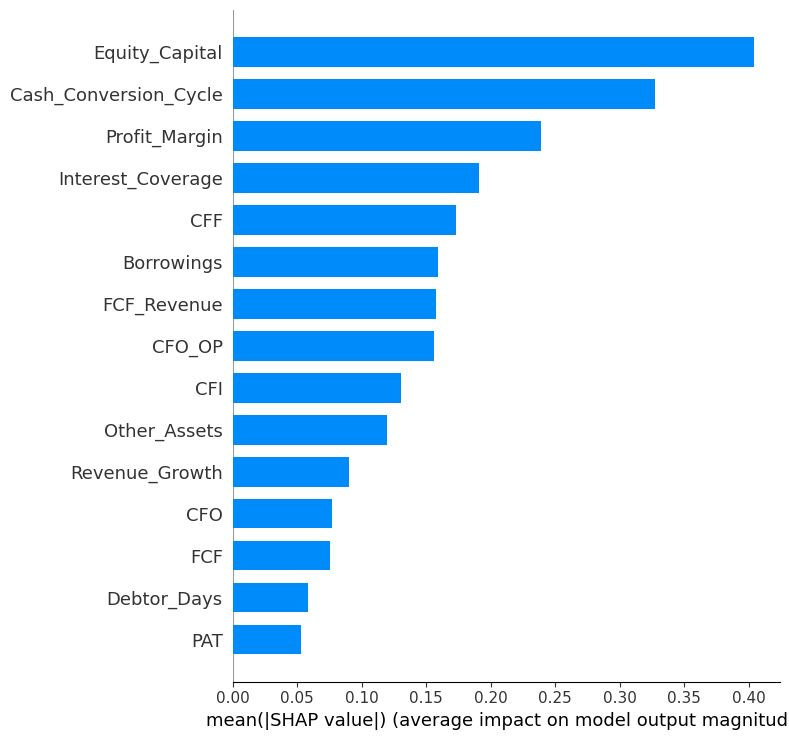


✅ SHAP analysis saved.


In [51]:
# ============================================================
# STEP 27 — SHAP FEATURE IMPORTANCE
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("STEP 27 — SHAP FEATURE IMPORTANCE")
print("=" * 80)

# Use 2024-2025 test data for explanation
# This does NOT retrain or modify the model.

X_shap = X_test.copy()

X_shap_imp = final_imputer.transform(
    X_shap
)

X_shap_imp = pd.DataFrame(
    X_shap_imp,
    columns=feature_columns
)

# ------------------------------------------------------------
# SHAP explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    final_xgb
)

shap_values = explainer.shap_values(
    X_shap_imp
)

# ------------------------------------------------------------
# Handle different SHAP versions
# ------------------------------------------------------------

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

# ------------------------------------------------------------
# Feature importance
# ------------------------------------------------------------

importance = np.abs(
    shap_values_plot
).mean(axis=0)

shap_importance = pd.DataFrame({

    "Feature": feature_columns,

    "Mean_Absolute_SHAP":
        importance

}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(
    drop=True
)

print("\nTOP 20 FEATURES")
print("=" * 80)

display(
    shap_importance.head(20)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

shap_importance.to_csv(
    "data/shap_feature_importance.csv",
    index=False
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

shap.summary_plot(
    shap_values_plot,
    X_shap_imp,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "data/shap_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✅ SHAP analysis saved."
)

In [56]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os

# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Financial Stress Early Warning System",
    page_icon="📊",
    layout="wide"
)

# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(
    os.path.abspath(__file__)
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "xgboost_financial_stress.joblib"
)

IMPUTER_PATH = os.path.join(
    BASE_DIR,
    "models",
    "financial_imputer.joblib"
)

THRESHOLD_PATH = os.path.join(
    BASE_DIR,
    "models",
    "financial_stress_threshold.joblib"
)

FEATURE_PATH = os.path.join(
    BASE_DIR,
    "models",
    "feature_columns.joblib"
)

SHAP_PATH = os.path.join(
    BASE_DIR,
    "data",
    "shap_feature_importance.csv"
)

# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():

    model = joblib.load(
        MODEL_PATH
    )

    imputer = joblib.load(
        IMPUTER_PATH
    )

    threshold = joblib.load(
        THRESHOLD_PATH
    )

    features = joblib.load(
        FEATURE_PATH
    )

    return (
        model,
        imputer,
        threshold,
        features
    )


try:

    model, imputer, threshold, features = (
        load_model()
    )

except Exception as e:

    st.error(
        "Model files could not be loaded."
    )

    st.code(str(e))

    st.stop()


# ============================================================
# HEADER
# ============================================================

st.title(
    "📊 Financial Stress Early Warning System"
)

st.markdown(
    """
    ### XGBoost-Based Financial Stress Prediction

    This system predicts the probability that a company
    will experience **financial stress in the following year**
    using historical financial indicators.
    """
)

st.divider()

# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "Company Information"
)

company_name = st.sidebar.text_input(
    "Company Name",
    "Sample Company"
)

financial_year = st.sidebar.number_input(
    "Financial Year",
    min_value=2015,
    max_value=2035,
    value=2025
)

st.sidebar.info(
    f"Model threshold: {threshold:.2f}"
)

# ============================================================
# INPUTS
# ============================================================

st.header(
    "Enter Financial Indicators"
)

st.write(
    "Enter the company's financial indicators below."
)

# ------------------------------------------------------------
# Main financial values
# ------------------------------------------------------------

col1, col2, col3 = st.columns(3)

with col1:

    revenue = st.number_input(
        "Revenue",
        min_value=0.0,
        value=100000.0
    )

    operating_profit = st.number_input(
        "Operating Profit",
        value=10000.0
    )

    other_income = st.number_input(
        "Other Income",
        value=1000.0
    )

    interest = st.number_input(
        "Interest",
        min_value=0.0,
        value=1000.0
    )

    depreciation = st.number_input(
        "Depreciation",
        min_value=0.0,
        value=2000.0
    )

with col2:

    profit_before_tax = st.number_input(
        "Profit Before Tax",
        value=8000.0
    )

    pat = st.number_input(
        "PAT",
        value=6000.0
    )

    equity_capital = st.number_input(
        "Equity Capital",
        min_value=0.0,
        value=5000.0
    )

    reserves = st.number_input(
        "Reserves",
        value=30000.0
    )

    borrowings = st.number_input(
        "Borrowings",
        min_value=0.0,
        value=10000.0
    )

with col3:

    cfo = st.number_input(
        "CFO",
        value=7000.0
    )

    cfi = st.number_input(
        "CFI",
        value=-3000.0
    )

    cff = st.number_input(
        "CFF",
        value=-2000.0
    )

    fcf = st.number_input(
        "FCF",
        value=5000.0
    )

    other_assets = st.number_input(
        "Other Assets",
        min_value=0.0,
        value=20000.0
    )

# ============================================================
# RATIOS
# ============================================================

st.subheader(
    "Financial Ratios"
)

r1, r2, r3 = st.columns(3)

with r1:

    profit_margin = st.number_input(
        "Profit Margin (%)",
        value=10.0
    )

    interest_coverage = st.number_input(
        "Interest Coverage",
        value=5.0
    )

with r2:

    cash_conversion_cycle = st.number_input(
        "Cash Conversion Cycle",
        value=60.0
    )

    debtor_days = st.number_input(
        "Debtor Days",
        value=60.0
    )

with r3:

    revenue_growth = st.number_input(
        "Revenue Growth (%)",
        value=10.0
    )

    fcf_revenue = st.number_input(
        "FCF / Revenue",
        value=5.0
    )

cfo_op = st.number_input(
    "CFO / Operating Profit",
    value=0.7
)

# ============================================================
# BUILD INPUT DATA
# ============================================================

if st.button(
    "🔍 Predict Financial Stress",
    type="primary",
    use_container_width=True
):

    # --------------------------------------------------------
    # Create empty feature dataframe
    # --------------------------------------------------------

    input_data = pd.DataFrame(
        np.nan,
        index=[0],
        columns=features
    )

    # --------------------------------------------------------
    # Fill known features
    # --------------------------------------------------------

    values = {

        "Revenue":
            revenue,

        "Operating_Profit":
            operating_profit,

        "Other_Income":
            other_income,

        "Interest":
            interest,

        "Depreciation":
            depreciation,

        "Profit_Before_Tax":
            profit_before_tax,

        "PAT":
            pat,

        "Equity_Capital":
            equity_capital,

        "Reserves":
            reserves,

        "Borrowings":
            borrowings,

        "CFO":
            cfo,

        "CFI":
            cfi,

        "CFF":
            cff,

        "FCF":
            fcf,

        "Other_Assets":
            other_assets,

        "Profit_Margin":
            profit_margin,

        "Interest_Coverage":
            interest_coverage,

        "Cash_Conversion_Cycle":
            cash_conversion_cycle,

        "Debtor_Days":
            debtor_days,

        "Revenue_Growth":
            revenue_growth,

        "FCF_Revenue":
            fcf_revenue,

        "CFO_OP":
            cfo_op
    }

    # --------------------------------------------------------
    # Insert available values
    # --------------------------------------------------------

    for feature, value in values.items():

        if feature in input_data.columns:

            input_data.loc[
                0,
                feature
            ] = value

    # --------------------------------------------------------
    # Convert to numeric
    # --------------------------------------------------------

    input_data = input_data.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # --------------------------------------------------------
    # Impute exactly like training
    # --------------------------------------------------------

    input_processed = imputer.transform(
        input_data
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probability = model.predict_proba(
        input_processed
    )[0, 1]

    prediction = (
        probability >= threshold
    )

    # ========================================================
    # RESULT
    # ========================================================

    st.divider()

    st.header(
        "Prediction Result"
    )

    result_col1, result_col2 = st.columns(2)

    with result_col1:

        st.metric(
            "Financial Stress Probability",
            f"{probability * 100:.2f}%"
        )

    with result_col2:

        if prediction:

            st.error(
                "⚠️ FINANCIALLY STRESSED"
            )

        else:

            st.success(
                "✅ LOW FINANCIAL STRESS"
            )

    # --------------------------------------------------------
    # Probability bar
    # --------------------------------------------------------

    st.progress(
        float(probability)
    )

    st.caption(
        f"Decision threshold: "
        f"{threshold:.2f}"
    )

    # ========================================================
    # INTERPRETATION
    # ========================================================

    st.subheader(
        "Interpretation"
    )

    if prediction:

        st.warning(
            """
            The model estimates that the company's
            probability of financial stress is above
            the selected decision threshold.

            Further financial analysis and monitoring
            are recommended.
            """
        )

    else:

        st.info(
            """
            The model estimates that the company's
            probability of financial stress is below
            the selected decision threshold.
            """
        )

# ============================================================
# MODEL INFORMATION
# ============================================================

st.divider()

st.header(
    "Model Information"
)

info1, info2, info3 = st.columns(3)

with info1:

    st.metric(
        "Model",
        "XGBoost"
    )

with info2:

    st.metric(
        "Training Period",
        "2017–2023"
    )

with info3:

    st.metric(
        "Final Test Period",
        "2024–2025"
    )

st.caption(
    """
    The model was evaluated using a chronological
    train/validation/test methodology. The final
    2024–2025 period was kept as a holdout test set.
    """
)

# ============================================================
# SHAP IMPORTANCE
# ============================================================

if os.path.exists(
    SHAP_PATH
):

    st.divider()

    st.header(
        "📈 Model Feature Importance"
    )

    shap_df = pd.read_csv(
        SHAP_PATH
    )

    st.write(
        "Top features influencing the model's predictions:"
    )

    st.bar_chart(
        shap_df
        .head(10)
        .set_index("Feature")[
            "Mean_Absolute_SHAP"
        ]
    )

    st.caption(
        """
        SHAP importance indicates how strongly features
        contribute to model predictions. It does not imply
        causation.
        """
    )

# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Financial Stress Early Warning System | "
    "XGBoost + SHAP"
)

2026-08-12 15:55:48.711 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name '__file__' is not defined

In [57]:
import os
import zipfile

# ============================================================
# CREATE ONE STREAMLIT PACKAGE
# ============================================================

files_to_include = [
    "models/xgboost_financial_stress.joblib",
    "models/financial_imputer.joblib",
    "models/financial_stress_threshold.joblib",
    "models/feature_columns.joblib",
    "models/feature_columns.csv",
    "data/shap_feature_importance.csv"
]

zip_name = "streamlit_files.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:

    for file in files_to_include:

        if os.path.exists(file):

            zipf.write(
                file,
                arcname=file
            )

            print("Added:", file)

        else:

            print("❌ NOT FOUND:", file)

print("\n" + "=" * 60)
print("STREAMLIT PACKAGE CREATED")
print("=" * 60)

print("File:", zip_name)

# Download automatically
from google.colab import files

files.download(zip_name)

Added: models/xgboost_financial_stress.joblib
Added: models/financial_imputer.joblib
Added: models/financial_stress_threshold.joblib
Added: models/feature_columns.joblib
Added: models/feature_columns.csv
Added: data/shap_feature_importance.csv

STREAMLIT PACKAGE CREATED
File: streamlit_files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>